#**M5 Phase: Unsupervised Machine Learning and Integrated Analysis for Government Grant Opportunities**

**US Government Grant Opportunities Dataset**

By: Team 11

##**Domain Questions**

*This notebook focuses on domain question 3, with integrations from questions 1 and 2.*

1. What structural eligibility archetypes emerge from federal grant data, and how do these archetypes differ across funding, agency sponsorship, program categories, and temporal patterns?
2. How have grant opportunity characteristics (agency, estimated funding, year posted, eligibility, category) evolved over time, and do distinct policy-era archetypes emerge in modern federal grantmaking?
3. **How can clustering grant descriptions uncover meaningful sub-topic categories beyond broad classifications, and what do these finer-grained categories reveal about patterns of funding concentration, gaps, and potentially underserved areas within the grant landscape?**
4. Do federal agencies operate under distinct funding strategy profiles based on how they distribute grant opportunities?

##**Problem Statement**

Our US Government Grants dataset allows analysis of funding patterns, agency priorities, and accessibility trends across nearly two decades of federal grant-making. Stakeholders include federal agencies, grant applicants (state/local governments, nonprofits, universities, businesses), grant writers, policy analysts, and taxpayers.



##**Dataset Description**

This dataset tracks government grants to different entities and organizations. There are two tables in our dataset: “grants.csv” (Grants) and “grant_opportunity_details.csv” (Details). This dataset captures the landscape of federal grant funding in the United States regarding grants posted from 2004 to 2023, showing how funding is distributed across agencies, programs, and recipients over time. The Grants table has 74669 rows and 17 columns. It includes numeric and categorical/object fields such as opportunity ID, agency code, agency name, estimated funding, estimated number of awards, posting date, and close date. The Details table has 2000 rows and 68 columns, including numeric and categorical/object columns like descriptions and many boolean fields of different types of eligibility and category.


# **Data Import and Cleaning**


### **Import and Inital Cleaning**

**Key Elements**
* Created an 'offical_elibility' column from boolean elibility columns
* Created an 'offical_category' column from boolean category columns
* Ensure consistent formating and data types across categories
* Filled missing descriptions with grant opportunity titles
*  Did *not* fill estimated funding NaNs with 0 to conduct variations in post-clustering analysis
*  Did *not* drop rows with duplicate descriptions to retain accurate topic counts

In [1]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

warnings.filterwarnings(
    "ignore",
    message="n_jobs value .* overridden .* random_state"
)

warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import re

# IMPORT DATA
grants = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv",
    low_memory=False
)

details = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv",
    low_memory=False
)


# CLEAN COLUMN NAMES
def clean_names(df):
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
        .str.replace(r"[^\w]", "", regex=True)
    )
    return df

grants = clean_names(grants)
details = clean_names(details)


# CLEAN DATE COLUMNS
date_cols = [col for col in details.columns if "date" in col]

for col in date_cols:
    details[col] = pd.to_datetime(
        details[col],
        errors="coerce"
    )


# ENSURE BOOLEAN TYPE FOR ELIGIBILITY COLUMNS
eligibility_cols = [
    "eligibility_individuals",
    "eligibility_state_governments",
    "eligibility_county_governments",
    "eligibility_independent_school_districts",
    "eligibility_city_or_township_governments",
    "eligibility_special_district_governments",
    "eligibility_native_american_tribal_governments_federally_recognized",
    "eligibility_native_american_tribal_organizations_other",
    "eligibility_nonprofits_501c3",
    "eligibility_nonprofits_non_501c3",
    "eligibility_for_profit",
    "eligibility_small_businesses",
    "eligibility_private_institutions_of_higher_education",
    "eligibility_public_institutions_of_higher_education",
    "eligibility_public_indian_housing_authorities",
    "eligibility_others",
    "eligibility_unrestricted"
]

for col in eligibility_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)


# ENSURE BOOLEAN TYPE FOR FUNDING INSTRUMENT TYPES
funding_cols = [
    "funding_cooperative_agreement",
    "funding_grant",
    "funding_procurement_contract",
    "funding_other"
]

for col in funding_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)


# ENSURE BOOLEAN TYPE FOR ALL CATEGORY COLUMNS
category_cols = [
    "category_agriculture",
    "category_arts",
    "category_business",
    "category_community_development",
    "category_consumer_protection",
    "category_disaster",
    "category_education",
    "category_employment",
    "category_energy",
    "category_environment",
    "category_food",
    "category_health",
    "category_housing",
    "category_humanities",
    "category_iija",
    "category_income_security",
    "category_info",
    "category_law",
    "category_natural_resources",
    "category_opportunity_zone",
    "category_regional_development",
    "category_science",
    "category_transportation",
    "category_other"
]

for col in category_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)

# CLEAN NUMERIC COLUMNS
numeric_cols = [
    "estimated_total_program_funding",
    "award_ceiling",
    "award_floor",
    "expected_number_of_awards"
]

for col in numeric_cols:
    if col in details.columns:
        details[col] = (
            details[col]
            .astype(str)
            .str.replace(r"[^\d.]", "", regex=True)
        )
        details[col] = pd.to_numeric(
            details[col],
            errors="coerce"
        )


# Fill missing descriptions
details['description'] = details['description'].fillna(details['funding_opportunity_title'])

# Create a single 'official_category' label by finding the first True category column
cat_cols = [c for c in details.columns if c.startswith('category_') and c != 'category_explanation']
details['official_category'] = details[cat_cols].idxmax(axis=1).str.replace('category_', '')

print("Grants shape:", grants.shape)
print("Details shape:", details.shape)

print("\nCategory columns:", len(category_cols))

details.head()

Grants shape: (74669, 17)
Details shape: (2000, 69)

Category columns: 24


,opportunity_id,funding_opportunity_number,funding_opportunity_title,opportunity_category,opportunity_category_explanation,expected_number_of_awards,cost_sharing_or_matching_requirement,version,posted_date,last_updated_date,...,category_info,category_law,category_natural_resources,category_opportunity_zone,category_regional_development,category_science,category_transportation,category_other,category_explanation,official_category
0,40112,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...,other
1,40113,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...,other
2,42048,FWS-R4-FLEXFUND,Southeast Region Flex Funds,Discretionary,NaN,25.0,False,3,2008-06-17,2008-06-18,...,False,False,True,False,False,False,False,False,NaN,natural_resources
3,42423,306-08-027-RFI,Alternative Development Program,Discretionary,NaN,1.0,False,1,2008-07-22,2008-07-22,...,False,False,False,False,False,False,False,False,NaN,agriculture
4,45657,04-563,Developing Country Collaborations in Plant Gen...,Discretionary,NaN,NaN,True,2,2004-03-22,2009-03-03,...,False,False,False,False,False,True,False,False,NaN,science


In [3]:
details['official_category'].value_counts()

,count
official_category,
health,590
science,447
education,442
other,114
environment,102
energy,51
food,47
natural_resources,40
agriculture,25


### **Text Cleaning/Preprocessing**

**Key Text Preprocessing Elements:**

* Unicode Normalization (e.g.,  "Å" vs "A")
* Normalize whitespace and punctionation (e.g., "-" vs "–")
* Removed urls and emails
* Removed soliciation codes
* Remove administrative/ boilerplate words and phrases

These steps help reduce dimensionality, ensure tokens with the same meaning have the same embeddings, and focus on the elements of grant descriptions that are informative to topic identification.

Update from M4: Text chunking did not improve cluster performance, so it was removed for M5.

In [4]:
import re
import unicodedata
import numpy as np

details["cleaned_description"] = details["description"]
text_cols = ["cleaned_description"]


# Unicode normalization (fix encoding issues)
for col in text_cols:
    if col in details.columns:
        details[col] = details[col].astype(str)
        details[col] = details[col].apply(lambda x: unicodedata.normalize("NFKC", x)) # Fix unicode normalization

# Fix encoding artifacts common in grant data
for col in text_cols:
    if col in details.columns:
        details[col] = details[col].str.replace("", "'", regex=False)
        details[col] = details[col].str.replace("", '"', regex=False)
        details[col] = details[col].str.replace("", '"', regex=False)
        details[col] = details[col].str.replace("–", "-", regex=False)
        details[col] = details[col].str.replace("—", "-", regex=False)

# Remove URLs and emails
for col in text_cols:
    if col in details.columns:
        details[col] = details[col].str.replace(r"http\S+", " ", regex=True)
        details[col] = details[col].str.replace(r"www\S+", " ", regex=True)
        details[col] = details[col].str.replace(r"\S+@\S+", " ", regex=True)

# Remove solicitation codes (NSF 04-510, PD 98-1331, etc.)
for col in text_cols:
    if col in details.columns:
        details[col] = details[col].str.replace(r"\b[A-Z]{2,5}[- ]?\d{2,6}\b", " ", regex=True)

# Remove administrative / boilerplate phrases
boilerplate_patterns = [
    r"subject to the availability of funds",
    r"availability of funds",
    r"applicants shall",
    r"applicants must",
    r"applicants should",
    r"applicants are encouraged to",
    r"proposal will be evaluated",
    r"proposals will be evaluated",
    r"full and open competition",
    r"request for applications",
    r"request for proposals",
    r"notice of funding opportunity",
    r"intellectual merit",
    r"broader impacts",
    r"data management plan",
    r"program solicitation",
    r"solicitation number",
    r"please visit",
    r"for more information"
]

combined_pattern = "|".join(boilerplate_patterns)

for col in text_cols:
    if col in details.columns:
        details[col] = details[col].str.replace(combined_pattern," ", regex=True, case=False)

# Normalize whitespace
for col in text_cols:
    if col in details.columns:
        details[col] = details[col].str.replace(r"\s+", " ", regex=True)
        details[col] = details[col].str.strip()


#**Grant Description Clustering for Sub-Topic Identification**

For grant sub-topic identification, I clustered each pre-assigned grant category separately. An inital attempt conducted in M2 revealed that clustering across the entire dataset gave weak and uninformative clusters. By separating clustering models, hyperparameters can be fine tuned for the specific grants in each category and better reveal the true areas of focus in the grant landscape, which is the core goal of the domain question.

This analysis focuses on the five grant categories with the most grants. This cut off was made to ensure each category had a minimum of 100 grants that could be used for clustering.

## **Health Category Clustering**

### **Create Health DataFrame**

In [5]:
details_health = details[details['official_category'] == 'health']
details_health.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,590.000000,63.000000,590.000000,590,590,585,584,564,6.000000e+01,2.750000e+02,6.500000e+01
mean,339878.200000,23.841270,1.452542,2022-06-07 15:42:06.101694976,2022-08-16 16:01:37.627118592,2024-09-06 09:43:23.076923136,2024-10-21 22:50:57.534246656,2024-12-22 01:39:34.468084992,5.900390e+07,8.360687e+06,2.312462e+06
min,58617.000000,0.000000,1.000000,2010-11-01 00:00:00,2012-01-27 00:00:00,2011-04-15 00:00:00,2018-06-15 00:00:00,2023-10-29 00:00:00,5.000000e+05,0.000000e+00,0.000000e+00
25%,335412.500000,4.000000,1.000000,2021-09-22 00:00:00,2021-12-12 18:00:00,2023-11-22 00:00:00,2023-12-05 00:00:00,2024-02-07 18:00:00,3.900000e+06,2.500000e+05,0.000000e+00
50%,344395.500000,10.000000,1.000000,2022-11-10 00:00:00,2023-01-11 00:00:00,2024-07-05 00:00:00,2024-07-12 12:00:00,2024-10-11 12:00:00,1.705750e+07,4.000000e+05,0.000000e+00
75%,348426.500000,28.000000,1.000000,2023-06-12 00:00:00,2023-06-29 18:00:00,2025-05-25 00:00:00,2025-05-26 00:00:00,2025-07-09 00:00:00,6.997500e+07,1.000000e+06,1.500000e+05
max,350383.000000,163.000000,18.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2031-12-06 00:00:00,2029-12-31 00:00:00,2040-01-01 00:00:00,5.000000e+08,5.000000e+08,7.300000e+07
std,20029.449628,31.423335,1.547313,NaN,NaN,NaN,NaN,NaN,1.041851e+08,4.220879e+07,9.894189e+06


### **Text Embedding**


In [6]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
embeddings_health = embedding_model.encode(
            details_health["cleaned_description"].tolist(),
            batch_size=64,
            normalize_embeddings=True
        )

embeddings_health = np.asarray(embeddings_health, dtype=np.float32)

### **Hierarchial Clustering**

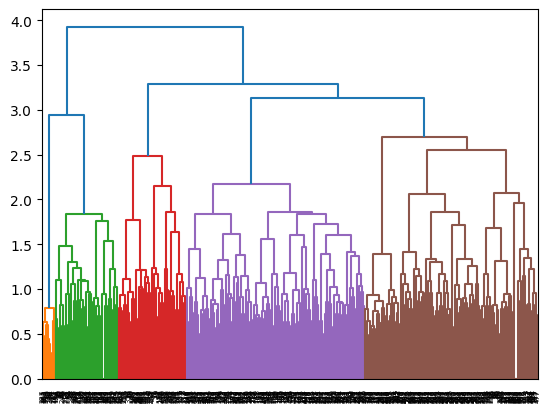

In [9]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(embeddings_health, 'average', metric='cosine')

_ = dendrogram(Z,)

In [11]:
n_clusters = 10

details_health['cluster_labels'] = fcluster(Z, n_clusters, criterion='maxclust').astype(str)

details_health['cluster_labels'].value_counts()

/tmp/ipython-input-711/2776305868.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health['cluster_labels'] = fcluster(Z, n_clusters, criterion='maxclust').astype(str)


,count
cluster_labels,
7,133
9,97
6,79
2,75
10,67
8,42
3,39
5,26
4,16


In [13]:
from sklearn.metrics import silhouette_score

silhouette_score(embeddings_health,details_health['cluster_labels'])

np.float32(0.038201)

#### Hierarchical Clustering Comparison

In [31]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

Z = linkage(embeddings_health, 'ward')

min_cluster_size = 10
similarity_threshold = 0.30  # adjust: 0.25 (looser) to 0.40 (stricter)

for n in range(3, 20):
    labels = fcluster(Z, n, criterion='maxclust')
    labels_series = pd.Series(labels)

    # --- Identify small clusters (< min_cluster_size) ---
    cluster_counts = labels_series.value_counts()
    small_clusters = cluster_counts[cluster_counts < min_cluster_size].index.tolist()

    # Keep points not in small clusters
    mask_keep = ~labels_series.isin(small_clusters).to_numpy()
    X_kept = embeddings_health[mask_keep]
    labels_kept = labels[mask_keep]

    # --- Silhouette: full + filtered ---
    sil_full = silhouette_score(embeddings_health, labels)

    can_recalc_sil = (len(labels_kept) >= 2) and (len(np.unique(labels_kept)) >= 2)
    sil_filtered = silhouette_score(X_kept, labels_kept) if can_recalc_sil else np.nan

    # --- Within-cluster cosine similarity on filtered set ---
    # For each cluster, compute mean pairwise cosine similarity (upper triangle).
    cluster_sims = {}
    for c in np.unique(labels_kept):
        idx = np.where(labels_kept == c)[0]
        if len(idx) < 2:
            continue  # not meaningful
        sims = cosine_similarity(X_kept[idx])
        mean_sim = sims[np.triu_indices(len(idx), k=1)].mean()
        cluster_sims[int(c)] = float(mean_sim)

    avg_cluster_similarity = np.mean(list(cluster_sims.values())) if len(cluster_sims) > 0 else np.nan

    low_similarity_clusters = {cid: sim for cid, sim in cluster_sims.items() if sim < similarity_threshold}

    # --- Print summary ---
    print(f"\nClusters: {n}")
    print(f"Silhouette (full): {sil_full:.4f}")
    if np.isnan(sil_filtered):
        print(f"Silhouette (filtered, removed clusters <{min_cluster_size}): N/A (not enough clusters/points)")
    else:
        print(f"Silhouette (filtered, removed clusters <{min_cluster_size}): {sil_filtered:.4f}")

    if np.isnan(avg_cluster_similarity):
        print("Avg within-cluster cosine similarity (filtered): N/A")
    else:
        print(f"Avg within-cluster cosine similarity (filtered): {avg_cluster_similarity:.4f}")

    # --- Report small clusters ---
    if len(small_clusters) > 0:
        counts_sorted = cluster_counts.sort_index()
        for cluster_id, count in counts_sorted.items():
            if count < min_cluster_size:
                print(f"  Small cluster: {int(cluster_id)} (Count: {int(count)})")

    # --- Report low-similarity clusters (filtered set) ---
    if len(low_similarity_clusters) > 0:
        print(f"  Low-similarity clusters (< {similarity_threshold}):")
        for cid, sim in sorted(low_similarity_clusters.items(), key=lambda x: x[1]):
            # Size on filtered set
            c_size = int(np.sum(labels_kept == cid))
            print(f"    Cluster {cid}: similarity={sim:.4f}, size={c_size}")
    else:
        print(f"  Low-similarity clusters (< {similarity_threshold}): none")


Clusters: 3
Silhouette (full): 0.0478
Silhouette (filtered, removed clusters <10): 0.0478
Avg within-cluster cosine similarity (filtered): 0.6488
  Low-similarity clusters (< 0.3): none

Clusters: 4
Silhouette (full): 0.0308
Silhouette (filtered, removed clusters <10): 0.0308
Avg within-cluster cosine similarity (filtered): 0.6569
  Low-similarity clusters (< 0.3): none

Clusters: 5
Silhouette (full): 0.0375
Silhouette (filtered, removed clusters <10): 0.0375
Avg within-cluster cosine similarity (filtered): 0.7103
  Low-similarity clusters (< 0.3): none

Clusters: 6
Silhouette (full): 0.0198
Silhouette (filtered, removed clusters <10): 0.0198
Avg within-cluster cosine similarity (filtered): 0.7217
  Low-similarity clusters (< 0.3): none

Clusters: 7
Silhouette (full): 0.0261
Silhouette (filtered, removed clusters <10): 0.0261
Avg within-cluster cosine similarity (filtered): 0.7155
  Low-similarity clusters (< 0.3): none

Clusters: 8
Silhouette (full): 0.0319
Silhouette (filtered, remo

Best Cluster Based on Cosine Similarity:

* Clusters: 6

* Silhouette (full): 0.0198

* Silhouette (filtered, removed clusters <10): 0.0198
* Avg within-cluster cosine similarity (filtered): 0.7217
* Low-similarity clusters (< 0.3): none

In [33]:
n_clusters = 6

details_health['cluster_labels'] = fcluster(Z, n_clusters, criterion='maxclust').astype(str)

details_health['cluster_labels'].value_counts()

/tmp/ipython-input-711/568440167.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health['cluster_labels'] = fcluster(Z, n_clusters, criterion='maxclust').astype(str)


,count
cluster_labels,
6,202
5,186
2,97
1,83
4,18
3,4


Hierarchal Clustering with Euclidean distance revealed poor results. In the final comparision pipeline, we will use cosine similarity.

### **HDBSCAN Clustering**

In [42]:
!pip install hdbscan --quiet

In [43]:
import umap
import hdbscan
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

n_neighbors_values = [5, 8, 10, 15]
n_components_values = [5, 8, 10]
min_cluster_size_values = [5, 8, 12, 15]
min_samples_values = [2, 3, 5]


In [55]:
import numpy as np
import pandas as pd
import umap
import hdbscan

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity

dbscan_results = []

# ---- helper: within-cluster cosine similarity (on ORIGINAL embeddings) ----
def within_cluster_cosine_summary(X_orig, labels, sim_threshold=0.30, min_cluster_size_for_eval=0):
    """
    Computes mean pairwise cosine similarity per cluster (excluding noise label -1),
    then returns:
      - avg_cluster_similarity: mean of per-cluster means
      - low_similarity_clusters: dict {cluster_id: mean_sim} where mean_sim < sim_threshold
    """
    cluster_ids = [c for c in np.unique(labels) if c != -1]
    cluster_sims = {}

    for c in cluster_ids:
        idx = np.where(labels == c)[0]
        if len(idx) < min_cluster_size_for_eval:
            continue
        sims = cosine_similarity(X_orig[idx])
        mean_sim = sims[np.triu_indices(len(idx), k=1)].mean()
        cluster_sims[int(c)] = float(mean_sim)

    avg_cluster_similarity = float(np.mean(list(cluster_sims.values()))) if len(cluster_sims) > 0 else np.nan
    low_similarity_clusters = {cid: sim for cid, sim in cluster_sims.items() if sim < sim_threshold}

    return avg_cluster_similarity, low_similarity_clusters


# ---- tuning knobs ----
sim_threshold = 0.30              # flag clusters below this mean cosine similarity
min_cluster_size_for_sim_eval = 0 # only compute similarity for clusters with >= 2 points

for n_neighbors in n_neighbors_values:
    for n_components in n_components_values:

        umap_model = umap.UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            min_dist=0.0,
            metric='cosine',
            random_state=42
        )

        reduced = umap_model.fit_transform(embeddings_health)

        for min_cluster_size in min_cluster_size_values:
            for min_samples in min_samples_values:

                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=min_cluster_size,
                    min_samples=min_samples,
                    metric='euclidean',               # clustering in UMAP space (Euclidean coords)
                    cluster_selection_method='eom'
                )

                labels_hdbscan = clusterer.fit_predict(reduced)

                # Number of non-noise clusters
                unique_labels = set(labels_hdbscan)
                num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

                # Skip if too few clusters (you had <3; keeping that)
                if num_clusters < 3:
                    continue

                # Skip if too many clusters
                if num_clusters > 50:
                    continue

                # Mask non-noise points
                mask = labels_hdbscan != -1

                # Need at least 2 clusters after removing noise for silhouette/CH
                if len(set(labels_hdbscan[mask])) < 2:
                    continue

                # --- Silhouette on ORIGINAL embeddings using COSINE ---
                # (Evaluates semantic separation in original space.)
                silhouette_cos = silhouette_score(
                    embeddings_health[mask],
                    labels_hdbscan[mask],
                    metric='cosine'
                )

                # --- Within-cluster cosine similarity on ORIGINAL embeddings ---
                avg_within_cos, low_sim_clusters = within_cluster_cosine_summary(
                    embeddings_health,
                    labels_hdbscan,
                    sim_threshold=sim_threshold,
                    min_cluster_size_for_eval=min_cluster_size_for_sim_eval
                )

                # --- Calinski-Harabasz on UMAP space (Euclidean geometry) ---
                # (CH assumes Euclidean; reduced is the correct space for that.)
                ch_hdbscan = calinski_harabasz_score(
                    reduced[mask],
                    labels_hdbscan[mask]
                )

                noise_pct = float(np.mean(labels_hdbscan == -1))
                persistence = float(np.mean(clusterer.cluster_persistence_)) if len(clusterer.cluster_persistence_) else np.nan

                dbscan_results.append({
                    "n_neighbors": n_neighbors,
                    "n_components": n_components,
                    "min_cluster_size": min_cluster_size,
                    "min_samples": min_samples,
                    "num_clusters": int(num_clusters),

                    "silhouette_cosine_orig": float(silhouette_cos),
                    "avg_within_cosine_orig": float(avg_within_cos),
                    "num_low_similarity_clusters": int(len(low_sim_clusters)),
                    "low_similarity_clusters": low_sim_clusters,  # dict: {cluster_id: mean_sim}

                    "calinski_harabasz_umap": float(ch_hdbscan),

                    "noise_pct": noise_pct,
                    "persistence": persistence
                })

# Optional: convert to DataFrame for sorting/filtering
dbscan_results_df = pd.DataFrame(dbscan_results)
# Example sort: prioritize coherence then separation
# dbscan_results_df.sort_values(["avg_within_cosine_orig", "silhouette_cosine_orig"], ascending=False).head(20)

In [56]:
dbscan_results_df.sort_values(["avg_within_cosine_orig"], ascending=False).head(20)

,n_neighbors,n_components,min_cluster_size,min_samples,num_clusters,silhouette_cosine_orig,avg_within_cosine_orig,num_low_similarity_clusters,low_similarity_clusters,calinski_harabasz_umap,noise_pct,persistence
83,10,10,5,3,46,0.122619,0.779554,0,{},1280.033081,0.133898,0.136118
60,10,5,5,3,48,0.176290,0.777275,0,{},1629.188354,0.186441,0.115883
118,15,10,5,2,50,0.110267,0.776630,0,{},498.443939,0.108475,0.104891
106,15,8,5,2,46,0.146613,0.774360,0,{},698.492981,0.159322,0.099243
72,10,8,5,3,45,0.141866,0.774354,0,{},1058.405762,0.140678,0.105497
84,10,10,5,5,38,0.150511,0.774241,0,{},1239.997314,0.194915,0.140890
119,15,10,5,3,42,0.108137,0.774182,0,{},491.303650,0.106780,0.114788
71,10,8,5,2,48,0.158433,0.774126,0,{},1255.091309,0.152542,0.114600
107,15,8,5,3,40,0.137242,0.773143,0,{},621.170105,0.179661,0.099045
94,15,5,5,2,43,0.140842,0.772333,0,{},614.163086,0.142373,0.092592


The resulting models favor niche sub-topics, with are less beneficial for answering our domain question. The hyperparameter grid is modified in the next section to address this.

### **HDBSCAN & Hierarchal Comparison Pipeline**



####**Evaluation Metrics**

**Hierarchal Clustering:**
* Silhouette Score (cosine): Measuring both cluster cohesion and separation
* Average within-cluster cosine similarity: how close points are to their own cluster center

Given the high dimensionality of text data and that the grants are within a category, some topics may overlap, which penalizes the silhouette score. To get a full picture of how these clusters perform, I evaluted both.

**HDBSCAN**
* Silhouette Score
* Average within-cluster cosine similarity
* Calinski Harabasz	Index: similar to silhouette score, measuring cohesion vs separation, but without a -1 to 1 bound
* Noise percentage

Particularly for density-based non-spherical clusters, the silhouette score may not give an accurate representation of cluster quality. The Calinski Harabasz Index can help validate the silhouette score with more detail. Average within-cluster cosine similarity is the primarly metric for evaluation, as it is more compatable with density-based clustering and quantifies how concrete our sub-topics are, rather than how different our sub-topics are. Noise percentage is useful for considering how many of our grants we are comfortable leaving un-classified.


####**Hyperparameters**

**Hierarchal:**
* **distance metric:** cosine *(to capture semantic relationships and interpretable 0-1 scores)*
* **linkage distance:** average *(for generally well-defined clusters, less sensitive to noise, and a good alternative to ward's which requires euclidean distance)*
* **number of clusters:** 4 - 16 *(for sufficient, yet interpretable topic separation)*

**HDBSCAN**
* min cluster size: 10, 12, 15, 20 *(comparing model strength when small clusters are treated as clusters vs as noise)*
* min samples: 5 *(low number to reduce the number of points treated as noise)*
* metric: euclidean *(magnitude matters for defining cluster density)*

**UMAP** (For HDBSCAN only)
* n_neighbors: 10, 15, 30 (local vs global structure)
* n_components: 5, 10 (number of dimensions)
* min distance: 0 (favor compact clustering)
* metric: cosine


####**Motivation**

M4 compared k-mean and HDBSCAN, with HDBSCAN performing better across all categories. While intuition suggests HDBSCAN will perform better on text data, hierarchal might perform well given our small dataset or reveal interesting patterns in broad vs niche sub-topics.

In [57]:
import numpy as np
import pandas as pd
import umap
import hdbscan

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity

# ============================
# SETTINGS
# ============================

UMAP_GRID = [
    {"n_neighbors": 10, "n_components": 5},
    {"n_neighbors": 10, "n_components": 10},
    {"n_neighbors": 15, "n_components": 5},
    {"n_neighbors": 15, "n_components": 10},
    {"n_neighbors": 30, "n_components": 5},
    {"n_neighbors": 30, "n_components": 10},
]

K_RANGE = range(4, 17)

HDBSCAN_GRID = [
    {"min_cluster_size": 10, "min_samples": 5},
    {"min_cluster_size": 12, "min_samples": 5},
    {"min_cluster_size": 15, "min_samples": 5},
    {"min_cluster_size": 20, "min_samples": 5},
]

SIM_THRESHOLD = 0.30


# ============================
# HELPER: cosine coherence
# ============================

def cosine_coherence(X, labels):

    sims = {}

    for c in np.unique(labels):

        idx = np.where(labels == c)[0]

        if len(idx) < 2:
            continue

        sim = cosine_similarity(X[idx])
        mean = sim[np.triu_indices(len(idx), 1)].mean()

        sims[c] = mean

    avg = np.mean(list(sims.values())) if sims else np.nan

    low = {k:v for k,v in sims.items() if v < SIM_THRESHOLD}

    return avg, low


# ============================
# RESULTS
# ============================

results = []

# =====================================================
# 1. HIERARCHICAL (COSINE)
# =====================================================

dist = pdist(embeddings_health, metric="cosine")

Z = linkage(dist, method="average")

for k in K_RANGE:

    labels = fcluster(Z, k, criterion="maxclust")

    sil = silhouette_score(
        embeddings_health,
        labels,
        metric="cosine"
    )

    coh, low = cosine_coherence(
        embeddings_health,
        labels
    )

    results.append({

        "method": "hierarchical",

        "clusters": k,

        "umap_neighbors": None,
        "umap_components": None,

        "min_cluster_size": None,

        "silhouette": sil,

        "cosine_coherence": coh,

        "calinski_harabasz": None,

        "noise_pct": 0,

        "low_similarity_clusters": len(low)
    })


# =====================================================
# 2. HDBSCAN + UMAP
# =====================================================

for params in UMAP_GRID:

    reducer = umap.UMAP(
        n_neighbors=params["n_neighbors"],
        n_components=params["n_components"],
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )

    X_umap = reducer.fit_transform(embeddings_health)

    for hparams in HDBSCAN_GRID:

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=hparams["min_cluster_size"],
            min_samples=hparams["min_samples"],
            metric="euclidean",
            random_state=42
        )

        labels = clusterer.fit_predict(X_umap)

        mask = labels != -1

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters < 4 or n_clusters > 16:
            continue

        sil = silhouette_score(
            X_umap[mask],
            labels[mask]
        )

        coh, low = cosine_coherence(
            embeddings_health[mask],
            labels[mask]
        )

        ch = calinski_harabasz_score(
            X_umap[mask],
            labels[mask]
        )

        results.append({

            "method": "hdbscan",

            "clusters": n_clusters,

            "umap_neighbors": params["n_neighbors"],
            "umap_components": params["n_components"],

            "min_cluster_size": hparams["min_cluster_size"],

            "silhouette": sil,

            "cosine_coherence": coh,

            "calinski_harabasz": ch,

            "noise_pct": np.mean(labels==-1),

            "low_similarity_clusters": len(low)
        })


# ============================
# FINAL TABLE
# ============================

df = pd.DataFrame(results)

df = df.sort_values(

    ["cosine_coherence","silhouette"],

    ascending=False

)

df.head(20)

,method,clusters,umap_neighbors,umap_components,min_cluster_size,silhouette,cosine_coherence,calinski_harabasz,noise_pct,low_similarity_clusters
22,hdbscan,16,30.0,10.0,10.0,0.541769,0.734896,453.423218,0.245763,0
18,hdbscan,16,15.0,10.0,12.0,0.552707,0.732231,556.369995,0.167797,0
19,hdbscan,16,15.0,10.0,15.0,0.552707,0.732231,556.369995,0.167797,0
9,hierarchical,13,NaN,NaN,NaN,0.083371,0.728518,NaN,0.000000,0
15,hdbscan,16,15.0,5.0,12.0,0.570073,0.727928,707.479797,0.155932,0
16,hdbscan,16,15.0,5.0,15.0,0.570073,0.727928,707.479797,0.155932,0
5,hierarchical,9,NaN,NaN,NaN,0.142052,0.727755,NaN,0.000000,0
11,hierarchical,15,NaN,NaN,NaN,0.078555,0.724602,NaN,0.000000,0
10,hierarchical,14,NaN,NaN,NaN,0.089241,0.722669,NaN,0.000000,0
12,hierarchical,16,NaN,NaN,NaN,0.084634,0.720034,NaN,0.000000,0


Best Model is run 18. This has the second highest cosine similarity score, but with a small noise percentage so more our our grants are categorized into sub-topics.

### **Final Model**

In [58]:
import umap
import hdbscan
import numpy as np

umap_model = umap.UMAP(
    n_components=10,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_health_umap = umap_model.fit_transform(embeddings_health)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=12,
    min_samples=5,
    metric='euclidean',
    random_state=42
)

health_clusters = hdbscan_model.fit_predict(embeddings_health_umap)

In [59]:
details_health["clusters"] = health_clusters

/tmp/ipython-input-711/1792403894.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health["clusters"] = health_clusters


In [60]:
details_health.groupby('clusters')['opportunity_id'].count()

,opportunity_id
clusters,
-1,99
0,17
1,17
2,18
3,19
4,20
5,28
6,21
7,55


### **Extracting Text for Cluster Labels**

**M4 Updates:**
Additional stop words and phrases were identified on a per-category basis to help limit the key word identification to informative and clear key words.

In [61]:
# Build cluster documents
health_cluster_docs = (
    details_health[details_health["clusters"] != -1]
    .groupby("clusters")["cleaned_description"]
    .apply(lambda x: " ".join(x))
)

In [62]:
# Remove generic/common words
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

domain_stopwords = {
    "research","clinical","program","support","development",
    "applications","funding","opportunity","trial","trials",
    "project","projects","purpose","include","related",
    "award","mechanism","announcement","grant"
}

custom_stopwords = list(ENGLISH_STOP_WORDS.union(domain_stopwords))

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

def extract_cluster_keywords(cluster_series, top_n=10):

    vec = TfidfVectorizer(
        stop_words=custom_stopwords,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.6,
        sublinear_tf=True
    )

    X = vec.fit_transform(cluster_series.values)

    terms = np.array(vec.get_feature_names_out())

    results = {}

    for i, cid in enumerate(cluster_series.index):
        scores = X[i].toarray().ravel()
        top_terms = terms[scores.argsort()[-top_n:][::-1]]
        results[cid] = top_terms.tolist()

    return results

health_keywords  = extract_cluster_keywords(health_cluster_docs)


In [64]:
def keywords_to_df(keyword_dict):
    return (
        pd.DataFrame.from_dict(keyword_dict, orient="index")
        .reset_index()
        .rename(columns={"index":"cluster"})
    )

health_kw_df  = keywords_to_df(health_keywords)

In [65]:
health_kw_df

,cluster,0,1,2,3,4,5,6,7,8,9
0,0,r25,educational activities,areas nih,mission areas,stated,creative educational,foa creative,meet nations,nations,courses
1,1,barriers facilitators,facilitators,persistence,hiv prevention,uptake,science studies,hormonal,initiative solicit,gaps knowledge,behavioral interventions
2,2,injuries,11,lifestyle,academic institutions,act,commercial,agenda,construction,industry,prevention cdc
3,3,housing,home,sv,fy,fiscal year,construction,primary health,gov,youth,care services
4,4,global,concept,document,government,process,annual,documents,agency,amendment,step
5,5,ahrq,violence,injury,forms,prevention control,policies,sexual,experiencing,youth,health services
6,6,vision,brain,preventing treating,proposed study,procedures,diagnosing,therapy,ind,clinicians,drug ind
7,7,intramural,nidcd,extramural,nidcr,r00,career transition,dentist,pathway,track equivalent,faculty positions
8,8,adrd,ad adrd,ad,dementias,dementias adrd,disease ad,alzheimer,alzheimer disease,late,cognitive
9,9,cancer,coordinating center,ccc,nichd,data coordinating,website,data management,uh3,ug3,coordinating


In [66]:
health_cluster_label_map = {
    0: "Biomedical Education & Training Programs",
    1: "HIV Prevention, Behavioral Science & Intervention Uptake",
    2: "Injury Prevention, Occupational Safety & Public Health Risk",
    3: "Housing, Community Infrastructure & Health Services Access",
    4: "Government Programs, Policy Frameworks & Administrative Initiatives",
    5: "Violence Prevention, Injury Epidemiology & Health Services Research",
    6: "Neurological Disorders, Vision & Clinical Therapeutics Development",
    7: "Career Development, Early-Stage Investigators & Faculty Transition",
    8: "Alzheimer’s Disease & Neurodegenerative Disorders",
    9: "Cancer Research Infrastructure & Data Coordinating Centers",
    10: "Mental Health Therapeutics & Experimental Treatment Development",
    11: "Biomedical Workforce Development, Mentoring & Research Capacity Building",
    12: "HIV/AIDS Immunology & Nonhuman Primate Models",
    13: "Genomics, Genetic Variation & Precision Medicine",
    14: "Small Business Innovation & Commercialization",
    15: "Neuroscience, Brain Function & Biomarkers"
}

details_health["cluster_label"] = (
    details_health["clusters"]
    .map(health_cluster_label_map)
    .fillna("Noise / Unassigned")
)

/tmp/ipython-input-711/1105923855.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health["cluster_label"] = (


### **Cluster Analysis**

#### **Cluster Counts & Top Clusters**

In [69]:
health_cluster_summary = (
    details_health
    .groupby(["cluster_label"])
    .size()
    .reset_index(name="n_grants")
    .sort_values("n_grants", ascending=False)
)

top_5_clusters = health_cluster_summary[health_cluster_summary['cluster_label'] != 'Noise / Unassigned'][['cluster_label', 'n_grants']].head(5)
top_5_clusters

,cluster_label,n_grants
0,Alzheimer’s Disease & Neurodegenerative Disorders,72
2,"Biomedical Workforce Development, Mentoring & ...",55
4,"Career Development, Early-Stage Investigators ...",55
5,"Genomics, Genetic Variation & Precision Medicine",38
3,Cancer Research Infrastructure & Data Coordina...,31


#### **Funding Concentration**

In [71]:
health_funding_summary = details_health.groupby("cluster_label").agg(n_opps=('opportunity_id', 'count'),
                                                                          avg_funding=('estimated_total_program_funding', 'mean'),
                                                                          med_funding=('estimated_total_program_funding', 'median'),
                                                                          total_funding=('estimated_total_program_funding', 'sum'),
                                                                          avg_awards=('expected_number_of_awards', 'mean'),
                                                                          med_awards=('expected_number_of_awards', 'median'))
health_funding_summary[health_funding_summary['total_funding'] != 0].sort_values("total_funding", ascending=False)


,n_opps,avg_funding,med_funding,total_funding,avg_awards,med_awards
cluster_label,,,,,,
"Housing, Community Infrastructure & Health Services Access",19,1.076005e+08,30520367.0,1.829209e+09,46.125000,43.5
Noise / Unassigned,99,1.185921e+08,75000000.0,8.301450e+08,30.666667,8.0
"Government Programs, Policy Frameworks & Administrative Initiatives",20,7.621345e+07,66640336.0,4.572807e+08,3.000000,1.5
"Injury Prevention, Occupational Safety & Public Health Risk",18,1.749612e+07,4000000.0,2.974340e+08,15.461538,12.0
"Biomedical Workforce Development, Mentoring & Research Capacity Building",55,2.000000e+07,20000000.0,4.000000e+07,20.000000,20.0
"Violence Prevention, Injury Epidemiology & Health Services Research",28,5.614286e+06,2100000.0,3.930000e+07,15.333333,4.0
Biomedical Education & Training Programs,17,2.250000e+07,22500000.0,2.250000e+07,9.000000,9.0
"Career Development, Early-Stage Investigators & Faculty Transition",55,8.432500e+06,8432500.0,1.686500e+07,31.000000,31.0
Alzheimer’s Disease & Neurodegenerative Disorders,72,7.500000e+06,7500000.0,7.500000e+06,8.000000,8.0


In [72]:
health_funding_df = health_funding_summary.reset_index()

In [74]:
funding_threshold = health_funding_df["total_funding"].median()
grant_threshold = health_funding_df["n_opps"].median()

def classify_quadrant(row):
    funding_level = "High Funding" if row["total_funding"] >= funding_threshold else "Low Funding"
    grant_level = "Many Grants" if row["n_opps"] >= grant_threshold else "Few Grants"
    return f"{funding_level} & {grant_level}"

health_funding_df["quadrant"] = health_funding_df.apply(classify_quadrant, axis=1)

matrix = (
    health_funding_df
    .groupby("quadrant")["cluster_label"]
    .apply(list)
    .reindex([
        "High Funding & Few Grants",
        "High Funding & Many Grants",
        "Low Funding & Few Grants",
        "Low Funding & Many Grants"
    ])
)

matrix_df = pd.DataFrame(matrix)
matrix_df.reset_index(inplace=True)
matrix_df

,quadrant,cluster_label
0,High Funding & Few Grants,"[Biomedical Education & Training Programs, Gov..."
1,High Funding & Many Grants,[Alzheimer’s Disease & Neurodegenerative Disor...
2,Low Funding & Few Grants,"[HIV Prevention, Behavioral Science & Interven..."
3,Low Funding & Many Grants,[Cancer Research Infrastructure & Data Coordin...


In [75]:
funding_threshold = health_funding_df["total_funding"].median()
grant_threshold = health_funding_df["avg_awards"].median()

def classify_quadrant(row):
    funding_level = "High Funding" if row["total_funding"] >= funding_threshold else "Low Funding"
    grant_level = "Many Awards" if row["avg_awards"] >= grant_threshold else "Few Awards"
    return f"{funding_level} & {grant_level}"

health_funding_df["quadrant"] = health_funding_df.apply(classify_quadrant, axis=1)

matrix = (
    health_funding_df
    .groupby("quadrant")["cluster_label"]
    .apply(list)
    .reindex([
        "High Funding & Few Awards",
        "High Funding & Many Awards",
        "Low Funding & Few Awards",
        "Low Funding & Many Awards"
    ])
)

matrix_df = pd.DataFrame(matrix)
matrix_df.reset_index(inplace=True)
matrix_df

,quadrant,cluster_label
0,High Funding & Few Awards,[Alzheimer’s Disease & Neurodegenerative Disor...
1,High Funding & Many Awards,"[Biomedical Workforce Development, Mentoring &..."
2,Low Funding & Few Awards,[Cancer Research Infrastructure & Data Coordin...
3,Low Funding & Many Awards,NaN


## **Science Category Clustering**

### **Create Science DataFrame**

In [76]:
details_science = details[details['official_category'] == 'science']
details_science.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,447.000000,221.000000,447.000000,447,447,343,340,330,2.820000e+02,1.420000e+02,1.560000e+02
mean,332922.145414,4597.434389,4.762864,2021-12-08 11:45:30.201342208,2023-03-15 22:42:41.073825536,2023-02-26 09:56:09.096209920,2024-03-28 19:58:35.294117632,2026-01-12 21:01:05.454545408,4.166612e+07,3.260322e+07,8.424234e+06
min,45657.000000,0.000000,1.000000,2004-03-22 00:00:00,2009-03-03 00:00:00,2009-07-15 00:00:00,2023-09-27 00:00:00,2023-10-02 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,336030.000000,6.000000,1.000000,2021-10-07 12:00:00,2023-05-19 00:00:00,2023-01-18 12:00:00,2023-10-31 00:00:00,2023-12-16 06:00:00,4.410000e+06,3.625000e+05,5.000000e+03
50%,345446.000000,18.000000,3.000000,2023-01-19 00:00:00,2023-05-20 00:00:00,2023-10-03 00:00:00,2023-12-30 12:00:00,2024-10-03 00:00:00,9.350000e+06,1.200000e+06,1.000000e+05
75%,348284.500000,40.000000,5.000000,2023-05-22 00:00:00,2023-08-10 00:00:00,2023-12-06 12:00:00,2024-03-29 00:00:00,2026-12-22 00:00:00,2.000000e+07,5.000000e+06,5.000000e+05
max,350369.000000,999999.000000,62.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2043-05-10 00:00:00,2043-05-10 00:00:00,2043-06-09 00:00:00,5.000000e+09,1.000000e+09,1.000000e+09
std,42926.128536,67262.678354,6.357239,NaN,NaN,NaN,NaN,NaN,3.006238e+08,1.469019e+08,8.041063e+07


### **Text Embedding**


In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [77]:
embeddings_science = embedding_model.encode(
            details_science["cleaned_description"].tolist(),
            batch_size=64,
            normalize_embeddings=True
        )

embeddings_science = np.asarray(embeddings_science, dtype=np.float32)

### **Full Comparison Pipeline**

Using the same pipeline from our Health Category, we can evalute Hierarchal vs HDBSCAN models for the Science Category. In M4, we concluded DBSCAN outperformed K-Means, so it is not included in this comparison.

In [78]:
import numpy as np
import pandas as pd
import umap
import hdbscan

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity

# ============================
# SETTINGS
# ============================

UMAP_GRID = [
    {"n_neighbors": 10, "n_components": 5},
    {"n_neighbors": 10, "n_components": 10},
    {"n_neighbors": 15, "n_components": 5},
    {"n_neighbors": 15, "n_components": 10},
    {"n_neighbors": 30, "n_components": 5},
    {"n_neighbors": 30, "n_components": 10},
]

K_RANGE = range(4, 17)

HDBSCAN_GRID = [
    {"min_cluster_size": 10, "min_samples": 5},
    {"min_cluster_size": 12, "min_samples": 5},
    {"min_cluster_size": 15, "min_samples": 5},
    {"min_cluster_size": 20, "min_samples": 5},
]

SIM_THRESHOLD = 0.30


# ============================
# HELPER: cosine coherence
# ============================

def cosine_coherence(X, labels):

    sims = {}

    for c in np.unique(labels):

        idx = np.where(labels == c)[0]

        if len(idx) < 2:
            continue

        sim = cosine_similarity(X[idx])
        mean = sim[np.triu_indices(len(idx), 1)].mean()

        sims[c] = mean

    avg = np.mean(list(sims.values())) if sims else np.nan

    low = {k:v for k,v in sims.items() if v < SIM_THRESHOLD}

    return avg, low


# ============================
# RESULTS
# ============================

results = []

# =====================================================
# 1. HIERARCHICAL (COSINE)
# =====================================================

dist = pdist(embeddings_science, metric="cosine")

Z = linkage(dist, method="average")

for k in K_RANGE:

    labels = fcluster(Z, k, criterion="maxclust")

    sil = silhouette_score(
        embeddings_science,
        labels,
        metric="cosine"
    )

    coh, low = cosine_coherence(
        embeddings_science,
        labels
    )

    results.append({

        "method": "hierarchical",

        "clusters": k,

        "umap_neighbors": None,
        "umap_components": None,

        "min_cluster_size": None,

        "silhouette": sil,

        "cosine_coherence": coh,

        "calinski_harabasz": None,

        "noise_pct": 0,

        "low_similarity_clusters": len(low)
    })


# =====================================================
# 2. HDBSCAN + UMAP
# =====================================================

for params in UMAP_GRID:

    reducer = umap.UMAP(
        n_neighbors=params["n_neighbors"],
        n_components=params["n_components"],
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )

    X_umap = reducer.fit_transform(embeddings_science)

    for hparams in HDBSCAN_GRID:

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=hparams["min_cluster_size"],
            min_samples=hparams["min_samples"],
            metric="euclidean",
            random_state=42
        )

        labels = clusterer.fit_predict(X_umap)

        mask = labels != -1

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters < 4 or n_clusters > 16:
            continue

        sil = silhouette_score(
            X_umap[mask],
            labels[mask]
        )

        coh, low = cosine_coherence(
            embeddings_science[mask],
            labels[mask]
        )

        ch = calinski_harabasz_score(
            X_umap[mask],
            labels[mask]
        )

        results.append({

            "method": "hdbscan",

            "clusters": n_clusters,

            "umap_neighbors": params["n_neighbors"],
            "umap_components": params["n_components"],

            "min_cluster_size": hparams["min_cluster_size"],

            "silhouette": sil,

            "cosine_coherence": coh,

            "calinski_harabasz": ch,

            "noise_pct": np.mean(labels==-1),

            "low_similarity_clusters": len(low)
        })


# ============================
# FINAL TABLE
# ============================

df = pd.DataFrame(results)

df = df.sort_values(

    ["cosine_coherence","silhouette"],

    ascending=False

)

df.head(20)

,method,clusters,umap_neighbors,umap_components,min_cluster_size,silhouette,cosine_coherence,calinski_harabasz,noise_pct,low_similarity_clusters
22,hdbscan,9,15.0,10.0,12.0,0.602388,0.721248,1930.377075,0.076063,0
23,hdbscan,9,15.0,10.0,15.0,0.602388,0.721248,1930.377075,0.076063,0
13,hdbscan,11,10.0,5.0,10.0,0.639449,0.720080,3699.887207,0.131991,0
14,hdbscan,11,10.0,5.0,12.0,0.639449,0.720080,3699.887207,0.131991,0
15,hdbscan,11,10.0,5.0,15.0,0.639449,0.720080,3699.887207,0.131991,0
17,hdbscan,11,10.0,10.0,10.0,0.623961,0.718667,2706.931641,0.131991,0
18,hdbscan,11,10.0,10.0,12.0,0.623961,0.718667,2706.931641,0.131991,0
19,hdbscan,11,10.0,10.0,15.0,0.623961,0.718667,2706.931641,0.131991,0
21,hdbscan,10,15.0,10.0,10.0,0.570546,0.717387,1832.827148,0.096197,0
20,hdbscan,9,10.0,10.0,20.0,0.608181,0.691215,951.619812,0.149888,0


Run 22 and 23 scored the same across all evaluation metrics. These models perform best in average cosine similarity and have a lower noise percentage than other HDSCAN models.

### **Best Model**

In [89]:
umap_model = umap.UMAP(
    n_components=10,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_science_umap = umap_model.fit_transform(embeddings_science)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric='euclidean',
    random_state=42
)

science_labels = hdbscan_model.fit_predict(embeddings_science_umap)

In [90]:
details_science["cluster"] = science_labels

/tmp/ipython-input-711/262291225.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_science["cluster"] = science_labels


### **Extracting Text for Cluster Labels**

In [91]:
# Build cluster documents
science_cluster_docs = (
    details_science[details_science["cluster"] != -1]
    .groupby("cluster")["cleaned_description"]
    .apply(lambda x: " ".join(x))
)

In [92]:
# remove common phrases
PHRASE_STOPWORDS = [
    "funding opportunity",
    "funding opportunity announcement",
    "award mechanism",
    "notice of funding opportunity",
]

def remove_phrases(text):
    text = text.lower()
    for p in PHRASE_STOPWORDS:
        text = text.replace(p, " ")
    return text

science_cluster_docs = science_cluster_docs.apply(remove_phrases)

In [93]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

def extract_cluster_keywords(cluster_series, top_n=10):

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_df=0.6,
        sublinear_tf=True
    )

    X = vec.fit_transform(cluster_series.values)

    terms = np.array(vec.get_feature_names_out())

    results = {}

    for i, cid in enumerate(cluster_series.index):
        scores = X[i].toarray().ravel()
        top_terms = terms[scores.argsort()[-top_n:][::-1]]
        results[cid] = top_terms.tolist()

    return results

science_keywords  = extract_cluster_keywords(science_cluster_docs, top_n=15)


In [96]:
science_keywords  = extract_cluster_keywords(science_cluster_docs, top_n=15)

def keywords_to_df(keyword_dict):
    return (
        pd.DataFrame.from_dict(keyword_dict, orient="index")
        .reset_index()
        .rename(columns={"index":"cluster"})
    )

science_keywords_df  = keywords_to_df(science_keywords)

In [97]:
science_keywords_df

,cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0,program element,roses,program elements,nra,tables,science division,download,smd,element,pdf,planetary science,particular program,mission directorate,pdf text,science mission
1,1,trials,clinical trials,clinical,military,clinical research,cancer,preliminary,human subjects,va,preliminary data,care,regulatory,refer,mentor,academy
2,2,roses,program elements,program element,nra,nspires,smd,tables,science division,download,mission directorate,science mission,nature work,space earth,lunar,elements dates
3,3,army,baa,dod,naval,defense,regulations,military,foa,air,cyber,agency announcement,broad agency,far,department defense,manufacturing
4,4,cise,stem education,ci,cybersecurity,systemic,teachers,native,ihes,cps,phase,teaching,intelligence,phase ii,research enterprise,workforce development
5,5,goali,cbet,thermal,discussed,transport,materials research,organismal,catalysis,reaction,biodiversity,manufacturing,engineering science,note proposals,prior submission,investigator award
6,6,atmospheric,geoscience,ocean,earth,climate,sea,geospace,geosciences,facilities,solar,species,earth sciences,facility,weather,non r1
7,7,language,psychology,anthropology,theoretically,support basic,sbe,cognitive,neural,empirically,neuroscience,cognitive neuroscience,pac,generalizable,cognition,methodological
8,8,mathematical,conferences workshops,dms,mathematical sciences,months advance,50 000,date proposals,economics,schools,proposals conferences,conference,months,winter,statistics,obtain


In [98]:
cluster_label_map = {
    0: "NASA Planetary Science & Mission-Specific Program Elements",
    1: "Clinical & Military Health Research",
    2: "NASA Space & Earth Science Research Opportunities",
    3: "Defense Science & Engineering",
    4: "Cybersecurity, Artificial Intelligence & STEM Workforce Development",
    5: "Engineering, Materials Science & Industrial Innovation",
    6: "Earth Science, Climate, Atmospheric & Ocean Research",
    7: "Cognitive Science, Neuroscience & Behavioral Research",
    8: "Mathematics & Statistics"
}

details_science["cluster_label"] = details_science["cluster"].map(cluster_label_map)

details_science["cluster_label"] = (
    details_science["cluster_label"]
    .fillna("Noise / Unassigned")
)


/tmp/ipython-input-711/1688181149.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_science["cluster_label"] = details_science["cluster"].map(cluster_label_map)
/tmp/ipython-input-711/1688181149.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_science["cluster_label"] = (


**Analysis**

The clusters identified in M4 are more specific than the clusters identified in M3. There are now 9 clusters instead of 7, and do not include outlier grants. They mostly capture the same topics identified previously, with some topics split up.

### **Cluster Analysis**

In [99]:
science_cluster_summary = (
    details_science.groupby("cluster_label").agg(
        n_opps=('opportunity_id', 'count'),
        avg_funding=('estimated_total_program_funding', 'mean'),
        med_funding=('estimated_total_program_funding', 'median'),
        total_funding=('estimated_total_program_funding', 'sum'),
        avg_awards=('expected_number_of_awards', 'mean'),
        med_awards=('expected_number_of_awards', 'median')
    )
    .sort_values("total_funding", ascending=False)
)

science_cluster_summary

,n_opps,avg_funding,med_funding,total_funding,avg_awards,med_awards
cluster_label,,,,,,
Defense Science & Engineering,62,4.994955e+08,10000000.0,5.494450e+09,47978.190476,51.0
"Cybersecurity, Artificial Intelligence & STEM Workforce Development",110,3.088895e+07,17000000.0,2.934450e+09,63.380952,30.0
"Engineering, Materials Science & Industrial Innovation",53,2.296154e+07,10400000.0,9.414230e+08,32.478261,15.0
"Earth Science, Climate, Atmospheric & Ocean Research",49,1.964236e+07,9000000.0,6.678401e+08,30.428571,25.0
NASA Planetary Science & Mission-Specific Program Elements,16,5.000000e+08,500000000.0,5.000000e+08,10.000000,10.0
Noise / Unassigned,34,2.081548e+07,6000000.0,4.371250e+08,99.294118,20.0
Clinical & Military Health Research,42,7.581268e+06,4000000.0,3.108320e+08,4.658537,3.0
NASA Space & Earth Science Research Opportunities,36,5.460000e+07,50000000.0,2.730000e+08,74.000000,47.5
Mathematics & Statistics,20,8.702308e+06,5000000.0,1.131300e+08,33.538462,20.0


**Analysis**

The top 3 sub-domains in the science category are STEM Education & Workforce Development Programs	(66 grants), Organismal Biology & Industry Partnerships (66 grants),
and Clinical & Translational Health Research (55 grants).

The sub-domains with the highest total funding are Defense & Aerospace research programs, STEM education, and Organismal Biology.

Defense & Areospace also the highest average funding and largest mean and median awards, making it the clear dominator of this category.

#### **Funding Concentration**

In [100]:
science_df = science_cluster_summary.reset_index()

In [101]:
funding_threshold = science_df["total_funding"].median()
grant_threshold = science_df["n_opps"].median()

def classify_quadrant(row):
    funding_level = "High Funding" if row["total_funding"] >= funding_threshold else "Low Funding"
    grant_level = "Many Grants" if row["n_opps"] >= grant_threshold else "Few Grants"
    return f"{funding_level} & {grant_level}"

science_df["quadrant"] = science_df.apply(classify_quadrant, axis=1)

matrix = (
    science_df
    .groupby("quadrant")["cluster_label"]
    .apply(list)
    .reindex([
        "High Funding & Few Grants",
        "High Funding & Many Grants",
        "Low Funding & Few Grants",
        "Low Funding & Many Grants"
    ])
)

matrix_df = pd.DataFrame(matrix)
matrix_df.reset_index(inplace=True)
matrix_df

,quadrant,cluster_label
0,High Funding & Few Grants,[NASA Planetary Science & Mission-Specific Pro...
1,High Funding & Many Grants,"[Defense Science & Engineering, Cybersecurity,..."
2,Low Funding & Few Grants,"[Noise / Unassigned, NASA Space & Earth Scienc..."
3,Low Funding & Many Grants,[Clinical & Military Health Research]


**Analysis**

The Sub-Category with high funding and few grants, indicating large concentrated programs, is NASA Mission-Specific Program.

Areas with high funding and many grants, indicating broad strategic priority areas are defense, CyberSecurity, STEM workforce development, materials science, and earth science

Areas with low funding and few grants, signaling underserved niche areas, are NASA research opportunties, mathematics, and cognitive neuroscience.

The Area with low funding and many grants, indicating highly compettive grants, is clinical & military health research.

In [102]:
funding_threshold = science_df["total_funding"].median()
grant_threshold = science_df["avg_awards"].median()

def classify_quadrant(row):
    funding_level = "High Funding" if row["total_funding"] >= funding_threshold else "Low Funding"
    grant_level = "Many Awards" if row["avg_awards"] >= grant_threshold else "Few Awards"
    return f"{funding_level} & {grant_level}"

science_df["quadrant"] = science_df.apply(classify_quadrant, axis=1)

matrix = (
    science_df
    .groupby("quadrant")["cluster_label"]
    .apply(list)
    .reindex([
        "High Funding & Few Awards",
        "High Funding & Many Awards",
        "Low Funding & Few Awards",
        "Low Funding & Many Awards"
    ])
)

matrix_df = pd.DataFrame(matrix)
matrix_df.reset_index(inplace=True)
matrix_df

,quadrant,cluster_label
0,High Funding & Few Awards,"[Engineering, Materials Science & Industrial I..."
1,High Funding & Many Awards,"[Defense Science & Engineering, Cybersecurity,..."
2,Low Funding & Few Awards,"[Clinical & Military Health Research, Cognitiv..."
3,Low Funding & Many Awards,"[Noise / Unassigned, NASA Space & Earth Scienc..."


**Analysis**

High Funding & Awards: Defense Science and Cybersecurity
Low Funding & Awards: NASA research opportunties and Mathematics

## **Education Category Clustering**

### **Creating Education DataFrame**

In [103]:
details_education = details[details['official_category'] == 'education']
details_education.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,442.000000,18.000000,442.000000,442,442,434,435,423,2.000000e+01,1.890000e+02,1.900000e+01
mean,338355.038462,7.055556,1.282805,2022-04-03 03:38:16.832579328,2022-07-21 07:52:23.891402752,2024-09-02 15:35:40.092165888,2024-12-24 05:11:10.344827648,2025-03-15 09:14:53.617021440,2.533998e+08,2.012663e+06,1.419737e+06
min,49325.000000,1.000000,1.000000,2009-09-02 00:00:00,2011-04-27 00:00:00,2009-07-29 00:00:00,2009-07-29 00:00:00,2023-10-29 00:00:00,2.000000e+04,0.000000e+00,0.000000e+00
25%,335476.000000,1.000000,1.000000,2021-08-27 06:00:00,2021-12-10 18:00:00,2023-12-11 00:00:00,2024-02-01 00:00:00,2024-03-22 00:00:00,1.000000e+07,2.750000e+05,0.000000e+00
50%,342972.500000,1.000000,1.000000,2022-08-06 00:00:00,2022-12-10 00:00:00,2024-09-07 00:00:00,2024-09-07 00:00:00,2024-10-13 00:00:00,2.312500e+07,3.500000e+05,2.500000e+04
75%,348039.000000,5.750000,1.000000,2023-05-09 12:00:00,2023-05-23 00:00:00,2025-06-08 06:00:00,2025-06-17 00:00:00,2025-08-09 12:00:00,5.500000e+07,5.000000e+05,1.000000e+06
max,350389.000000,52.000000,18.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2028-02-08 00:00:00,2121-10-12 00:00:00,2121-11-11 00:00:00,4.350000e+09,6.000000e+07,1.000000e+07
std,24675.063168,12.581369,1.104156,NaN,NaN,NaN,NaN,NaN,9.650793e+08,7.345700e+06,2.944446e+06


### **Text Embedding**

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [104]:
embeddings_education = embedding_model.encode(
            details_education["cleaned_description"].tolist(),
            batch_size=64,
            normalize_embeddings=True
        )

embeddings_education = np.asarray(embeddings_education, dtype=np.float32)

### **Full Comparison Pipeline**

Once again, the same comparison pipeline was used here. In M4, we concluded DBSCAN outperformed K-Means, so it is not included in this comparison.

In [105]:
import numpy as np
import pandas as pd
import umap
import hdbscan

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity

# ============================
# SETTINGS
# ============================

UMAP_GRID = [
    {"n_neighbors": 10, "n_components": 5},
    {"n_neighbors": 10, "n_components": 10},
    {"n_neighbors": 15, "n_components": 5},
    {"n_neighbors": 15, "n_components": 10},
    {"n_neighbors": 30, "n_components": 5},
    {"n_neighbors": 30, "n_components": 10},
]

K_RANGE = range(4, 17)

HDBSCAN_GRID = [
    {"min_cluster_size": 10, "min_samples": 5},
    {"min_cluster_size": 12, "min_samples": 5},
    {"min_cluster_size": 15, "min_samples": 5},
    {"min_cluster_size": 20, "min_samples": 5},
]

SIM_THRESHOLD = 0.30


# ============================
# HELPER: cosine coherence
# ============================

def cosine_coherence(X, labels):

    sims = {}

    for c in np.unique(labels):

        idx = np.where(labels == c)[0]

        if len(idx) < 2:
            continue

        sim = cosine_similarity(X[idx])
        mean = sim[np.triu_indices(len(idx), 1)].mean()

        sims[c] = mean

    avg = np.mean(list(sims.values())) if sims else np.nan

    low = {k:v for k,v in sims.items() if v < SIM_THRESHOLD}

    return avg, low


# ============================
# RESULTS
# ============================

results = []

# =====================================================
# 1. HIERARCHICAL (COSINE)
# =====================================================

dist = pdist(embeddings_education, metric="cosine")

Z = linkage(dist, method="average")

for k in K_RANGE:

    labels = fcluster(Z, k, criterion="maxclust")

    sil = silhouette_score(
        embeddings_education,
        labels,
        metric="cosine"
    )

    coh, low = cosine_coherence(
        embeddings_education,
        labels
    )

    results.append({

        "method": "hierarchical",

        "clusters": k,

        "umap_neighbors": None,
        "umap_components": None,

        "min_cluster_size": None,

        "silhouette": sil,

        "cosine_coherence": coh,

        "calinski_harabasz": None,

        "noise_pct": 0,

        "low_similarity_clusters": len(low)
    })


# =====================================================
# 2. HDBSCAN + UMAP
# =====================================================

for params in UMAP_GRID:

    reducer = umap.UMAP(
        n_neighbors=params["n_neighbors"],
        n_components=params["n_components"],
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )

    X_umap = reducer.fit_transform(embeddings_education)

    for hparams in HDBSCAN_GRID:

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=hparams["min_cluster_size"],
            min_samples=hparams["min_samples"],
            metric="euclidean",
            random_state=42
        )

        labels = clusterer.fit_predict(X_umap)

        mask = labels != -1

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters < 4 or n_clusters > 16:
            continue

        sil = silhouette_score(
            X_umap[mask],
            labels[mask]
        )

        coh, low = cosine_coherence(
            embeddings_education[mask],
            labels[mask]
        )

        ch = calinski_harabasz_score(
            X_umap[mask],
            labels[mask]
        )

        results.append({

            "method": "hdbscan",

            "clusters": n_clusters,

            "umap_neighbors": params["n_neighbors"],
            "umap_components": params["n_components"],

            "min_cluster_size": hparams["min_cluster_size"],

            "silhouette": sil,

            "cosine_coherence": coh,

            "calinski_harabasz": ch,

            "noise_pct": np.mean(labels==-1),

            "low_similarity_clusters": len(low)
        })


# ============================
# FINAL TABLE
# ============================

df = pd.DataFrame(results)

df = df.sort_values(

    ["cosine_coherence","silhouette"],

    ascending=False

)

df.head(20)

,method,clusters,umap_neighbors,umap_components,min_cluster_size,silhouette,cosine_coherence,calinski_harabasz,noise_pct,low_similarity_clusters
9,hierarchical,13,NaN,NaN,NaN,0.064641,0.784871,NaN,0.000000,0
8,hierarchical,12,NaN,NaN,NaN,0.095353,0.784795,NaN,0.000000,0
7,hierarchical,11,NaN,NaN,NaN,0.123822,0.784714,NaN,0.000000,0
6,hierarchical,10,NaN,NaN,NaN,0.139931,0.779431,NaN,0.000000,0
10,hierarchical,14,NaN,NaN,NaN,0.078062,0.768067,NaN,0.000000,0
11,hierarchical,15,NaN,NaN,NaN,0.071012,0.760894,NaN,0.000000,0
21,hdbscan,15,15.0,5.0,10.0,0.518189,0.754722,936.901733,0.171946,0
13,hdbscan,16,10.0,5.0,10.0,0.540924,0.748555,1095.300415,0.151584,0
12,hierarchical,16,NaN,NaN,NaN,0.070640,0.746232,NaN,0.000000,0
25,hdbscan,11,15.0,10.0,10.0,0.509198,0.741424,676.164062,0.126697,0


Hierarchal appears to perform better for this category. Below, we investigate one of these models and find that it identified one large cluster and several smaller noise clusters. Because of this, the model chosen for analysis was run 15, which balances an appropriate number of clusters for the number of grants in this data set with average cosine similarity, silhoutte score, and noise percentage.

In [107]:
dist = pdist(embeddings_education, metric="cosine")

Z = linkage(dist, method="average")

labels = fcluster(Z, 10, criterion="maxclust")

details_education['clusters'] = labels

details_education['clusters'].value_counts()

/tmp/ipython-input-711/1912381112.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_education['clusters'] = labels


,count
clusters,
2,431
6,2
1,2
10,1
5,1
9,1
4,1
3,1
8,1


### **Best Model**

In [113]:
umap_model = umap.UMAP(
    n_components=5,
    n_neighbors=10,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_education_umap = umap_model.fit_transform(embeddings_education)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric='euclidean',
    random_state=42
)

education_labels = hdbscan_model.fit_predict(embeddings_education_umap)

In [114]:
details_education["cluster"] = education_labels

/tmp/ipython-input-711/3358709291.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_education["cluster"] = education_labels


In [115]:
details_education["cluster"].value_counts()

,count
cluster,
5,84
-1,76
1,40
6,38
9,33
0,29
10,29
2,25
7,25


### **Extracting Text for Cluster Labels**

In [116]:
# Build cluster documents
education_cluster_docs = (
    details_education[details_education["cluster"] != -1]
    .groupby("cluster")["cleaned_description"]
    .apply(lambda x: " ".join(x))
)

In [117]:
# remove common phrases
PHRASE_STOPWORDS = [
    "funding opportunity",
    "funding opportunity announcement",
    "award mechanism",
    "notice of funding opportunity",
]

def remove_phrases(text):
    text = text.lower()
    for p in PHRASE_STOPWORDS:
        text = text.replace(p, " ")
    return text

education_cluster_docs = education_cluster_docs.apply(remove_phrases)

In [118]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

def extract_cluster_keywords(cluster_series, top_n=6):

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_df=0.6,
        sublinear_tf=True
    )

    X = vec.fit_transform(cluster_series.values)

    terms = np.array(vec.get_feature_names_out())

    results = {}

    for i, cid in enumerate(cluster_series.index):
        scores = X[i].toarray().ravel()
        top_terms = terms[scores.argsort()[-top_n:][::-1]]
        results[cid] = top_terms.tolist()

    return results

education_keywords  = extract_cluster_keywords(education_cluster_docs)


In [121]:
education_keywords  = extract_cluster_keywords(education_cluster_docs, top_n=15)

def keywords_to_df(keyword_dict):
    return (
        pd.DataFrame.from_dict(keyword_dict, orient="index")
        .reset_index()
        .rename(columns={"index":"cluster"})
    )

education_keywords_df  = keywords_to_df(education_keywords)

In [122]:
education_keywords_df

,cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0,education,federal,notice,school,document,msis,note,contact,assistance,proposal,competition,awarding,learning,description,stem
1,1,positions,postdoctoral,r00,education,r00 program,nih research,mission areas,educational,program designed,tenure,tenure track,cohort,postdoctoral research,positions independent,support transition
2,2,predoctoral,support protected,mentored,supervised,independent clinical,mentored research,protected time,protected,fellowship,doctoral degree,k01,productive,purpose nih,research career,experience clinical
3,3,human participants,processes products,products mind,studies involving,outcomes humans,assess biomedical,outside,involving human,behavioral outcomes,involving,definition,variables,variables assess,prospectively assign,proposed project
4,4,nci funded,tenure track,specialist,tenure,women,faculty position,position,positions,requests,research positions,track faculty,track,mentor,salary research,ic
5,5,hiv aids,abuse,drug abuse,aids,substance,substance use,hiv,nida,drug,sud,alcohol,racial,infection,sexual,comorbidities
6,6,pain,opioid,heal,devices,treat,device,compounds,alcohol,addiction,aud,nervous,non clinical,crisis,biomarker,discovery
7,7,circuit,recording,brain,neural,manipulation,invasive,nervous,brain initiative,reissue rfa,neuroscience,brain cell,central nervous,dynamic,cns,reissue
8,8,tumor,microbial,immune,infections,metabolism,radiation,infection,investigations,cancer therapy,diet,anti,imaging,growth,biology,synthetic
9,9,markers,detection,assay,biomarkers,informatics,validation,biospecimens,cancers,genomic,cancer treatment,early detection,pediatric,biomarker,assays,mammalian


In [123]:
cluster_label_map = {
    0: "Federal Classroom Education Programs",
    1: "Postdoctoral Career Transition Programs",
    2: "Predoctoral Fellowships & Research Training",
    3: "Human Subjects & Behavioral Research Training",
    4: "Faculty Development & Academic Workforce Programs",
    5: "HIV, Substance Use & Addiction Research Training Programs",
    6: "Pain, Opioid & Addiction Treatment Research Training",
    7: "Neuroscience Training Programs",
    8: "Cancer & Biomedical Research Training",
    9: "Cancer Genomics & Biomarker Training",
    10: "Cancer Disparities & Population Health Training"
}

details_education["cluster_label"] = details_education["cluster"].map(cluster_label_map)

details_education["cluster_label"] = (
    details_education["cluster_label"]
    .fillna("Noise / Unassigned")
)


/tmp/ipython-input-711/3226103872.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_education["cluster_label"] = details_education["cluster"].map(cluster_label_map)
/tmp/ipython-input-711/3226103872.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_education["cluster_label"] = (


**Analysis**

The clusters identified in M4 are much more specific than the clusters identified in M3. There are now 18 clusters instead 6, and although there are some overlapping themes, these better highlight the actual sub-domain rather than some of the vague "catch all" categories in M3.

###**Cluster Analysis**

In [124]:
education_cluster_summary = (
    details_education.groupby("cluster_label").agg(
        n_opps=('opportunity_id', 'count'),
        avg_funding=('estimated_total_program_funding', 'mean'),
        med_funding=('estimated_total_program_funding', 'median'),
        total_funding=('estimated_total_program_funding', 'sum'),
        avg_awards=('expected_number_of_awards', 'mean'),
        med_awards=('expected_number_of_awards', 'median')
    )
    .sort_values("total_funding", ascending=False)
)

education_cluster_summary['n_opps'].sort_values(ascending=False)

,n_opps
cluster_label,
"HIV, Substance Use & Addiction Research Training Programs",84
Noise / Unassigned,76
Postdoctoral Career Transition Programs,40
"Pain, Opioid & Addiction Treatment Research Training",38
Cancer Genomics & Biomarker Training,33
Federal Classroom Education Programs,29
Cancer Disparities & Population Health Training,29
Neuroscience Training Programs,25
Predoctoral Fellowships & Research Training,25


While noise occupies the largest cluster, the top 5 education sub-domains are around career development, federal education programs, undergraduate education programs, and clinical research education.

Overall, these granular clusters could be grouped in larger clusters to create a hierarchy, such as:  
- Career/Workforce Development
- Cancer
- Substance Use & Addiction
- Neuroscience

They can also be grouped into Discovery or Implementation, i.e. whether they focus on knowledge generation or knowledge deployment.

In [125]:
education_cluster_summary[~education_cluster_summary['avg_funding'].isna()].sort_values(by='total_funding', ascending=False)

,n_opps,avg_funding,med_funding,total_funding,avg_awards,med_awards
cluster_label,,,,,,
Federal Classroom Education Programs,29,3.134997e+08,33000000.0,5.015996e+09,7.5625,1.0
Neuroscience Training Programs,25,2.200000e+07,22000000.0,2.200000e+07,5.0000,5.0
"Pain, Opioid & Addiction Treatment Research Training",38,1.000000e+07,10000000.0,2.000000e+07,NaN,NaN
"HIV, Substance Use & Addiction Research Training Programs",84,1.000000e+07,10000000.0,1.000000e+07,1.0000,1.0


Many of the grants in this section are missing estimated funding data, but out of the sub-domains with adequate data, Federal Education Program Administration dominates average funding, total funding, and average awards.

## **Other Category Clustering**

### **Creating Other DataFrame**

In [126]:
details_other = details[details['official_category'] == 'other']
details_other.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,114.000000,63.000000,114.000000,114,114,71,71,46,5.400000e+01,1.050000e+02,1.040000e+02
mean,314469.192982,60.158730,3.307018,2020-10-20 23:47:22.105263104,2021-04-12 06:18:56.842105344,2027-08-16 12:30:25.352112640,2028-02-24 11:49:51.549295872,2024-03-13 15:39:07.826086912,4.336868e+07,1.128512e+07,9.660337e+05
min,40112.000000,0.000000,1.000000,2007-11-28 00:00:00,2007-11-28 00:00:00,2017-12-18 00:00:00,2017-08-13 00:00:00,2023-10-29 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,317601.250000,1.000000,1.000000,2019-07-16 12:00:00,2020-12-27 00:00:00,2023-06-15 12:00:00,2023-09-30 00:00:00,2023-11-18 06:00:00,3.937500e+05,5.000000e+04,0.000000e+00
50%,341915.000000,5.000000,2.000000,2022-07-05 00:00:00,2023-01-30 12:00:00,2023-10-06 00:00:00,2023-11-16 00:00:00,2024-01-16 12:00:00,4.870000e+06,5.000000e+05,3.000000e+03
75%,348591.750000,10.000000,4.750000,2023-06-06 12:00:00,2023-07-23 00:00:00,2023-12-26 12:00:00,2024-03-21 12:00:00,2024-05-08 00:00:00,1.950000e+07,5.000000e+06,2.125000e+05
max,350362.000000,3000.000000,19.000000,2023-09-27 00:00:00,2023-09-28 00:00:00,2099-01-01 00:00:00,2099-01-01 00:00:00,2025-05-26 00:00:00,5.000000e+08,3.749813e+08,3.080000e+07
std,70362.197925,377.072903,3.320964,NaN,NaN,NaN,NaN,NaN,1.098767e+08,4.072138e+07,3.623084e+06


### **Text Embedding**

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [127]:
embeddings_other = embedding_model.encode(
            details_other["cleaned_description"].tolist(),
            batch_size=64,
            normalize_embeddings=True
        )

embeddings_other = np.asarray(embeddings_other, dtype=np.float32)

### **Full Comparison Pipeline**

The same comparison pipeline was used for the other category with small tweaks in the hyperparameters. Due to the smaller size of this category, the min cluster size parameters and k range were reduced.

In [133]:
import numpy as np
import pandas as pd
import umap
import hdbscan

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity

# ============================
# SETTINGS
# ============================

UMAP_GRID = [
    {"n_neighbors": 10, "n_components": 5},
    {"n_neighbors": 10, "n_components": 10},
    {"n_neighbors": 15, "n_components": 5},
    {"n_neighbors": 15, "n_components": 10},
    {"n_neighbors": 30, "n_components": 5},
    {"n_neighbors": 30, "n_components": 10},
]

K_RANGE = range(3, 15)

HDBSCAN_GRID = [
    {"min_cluster_size": 6, "min_samples": 5},
    {"min_cluster_size": 8, "min_samples": 5},
    {"min_cluster_size": 10, "min_samples": 5},
    {"min_cluster_size": 12, "min_samples": 5},
]

SIM_THRESHOLD = 0.25


# ============================
# HELPER: cosine coherence
# ============================

def cosine_coherence(X, labels):

    sims = {}

    for c in np.unique(labels):

        idx = np.where(labels == c)[0]

        if len(idx) < 2:
            continue

        sim = cosine_similarity(X[idx])
        mean = sim[np.triu_indices(len(idx), 1)].mean()

        sims[c] = mean

    avg = np.mean(list(sims.values())) if sims else np.nan

    low = {k:v for k,v in sims.items() if v < SIM_THRESHOLD}

    return avg, low


# ============================
# RESULTS
# ============================

results = []

# =====================================================
# 1. HIERARCHICAL (COSINE)
# =====================================================

dist = pdist(embeddings_other, metric="cosine")

Z = linkage(dist, method="average")

for k in K_RANGE:

    labels = fcluster(Z, k, criterion="maxclust")

    sil = silhouette_score(
        embeddings_other,
        labels,
        metric="cosine"
    )

    coh, low = cosine_coherence(
        embeddings_other,
        labels
    )

    results.append({

        "method": "hierarchical",

        "clusters": k,

        "umap_neighbors": None,
        "umap_components": None,

        "min_cluster_size": None,

        "silhouette": sil,

        "cosine_coherence": coh,

        "calinski_harabasz": None,

        "noise_pct": 0,

        "low_similarity_clusters": len(low)
    })


# =====================================================
# 2. HDBSCAN + UMAP
# =====================================================

for params in UMAP_GRID:

    reducer = umap.UMAP(
        n_neighbors=params["n_neighbors"],
        n_components=params["n_components"],
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )

    X_umap = reducer.fit_transform(embeddings_other)

    for hparams in HDBSCAN_GRID:

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=hparams["min_cluster_size"],
            min_samples=hparams["min_samples"],
            metric="euclidean",
            random_state=42
        )

        labels = clusterer.fit_predict(X_umap)

        mask = labels != -1

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters < 3 or n_clusters > 16:
            continue

        sil = silhouette_score(
            X_umap[mask],
            labels[mask]
        )

        coh, low = cosine_coherence(
            embeddings_other[mask],
            labels[mask]
        )

        ch = calinski_harabasz_score(
            X_umap[mask],
            labels[mask]
        )

        results.append({

            "method": "hdbscan",

            "clusters": n_clusters,

            "umap_neighbors": params["n_neighbors"],
            "umap_components": params["n_components"],

            "min_cluster_size": hparams["min_cluster_size"],

            "silhouette": sil,

            "cosine_coherence": coh,

            "calinski_harabasz": ch,

            "noise_pct": np.mean(labels==-1),

            "low_similarity_clusters": len(low)
        })


# ============================
# FINAL TABLE
# ============================

df = pd.DataFrame(results)

df = df.sort_values(

    ["cosine_coherence","silhouette"],

    ascending=False

)

df.head(20)

,method,clusters,umap_neighbors,umap_components,min_cluster_size,silhouette,cosine_coherence,calinski_harabasz,noise_pct,low_similarity_clusters
9,hierarchical,12,NaN,NaN,NaN,0.105491,0.741516,NaN,0.000000,0
10,hierarchical,13,NaN,NaN,NaN,0.094544,0.729239,NaN,0.000000,0
11,hierarchical,14,NaN,NaN,NaN,0.104365,0.726348,NaN,0.000000,0
8,hierarchical,11,NaN,NaN,NaN,0.115142,0.719250,NaN,0.000000,0
5,hierarchical,8,NaN,NaN,NaN,0.114236,0.697242,NaN,0.000000,0
24,hdbscan,4,15.0,10.0,6.0,0.633003,0.687806,394.178436,0.184211,0
25,hdbscan,4,15.0,10.0,8.0,0.633003,0.687806,394.178436,0.184211,0
20,hdbscan,4,15.0,5.0,6.0,0.617338,0.681491,482.457550,0.157895,0
21,hdbscan,4,15.0,5.0,8.0,0.617338,0.681491,482.457550,0.157895,0
28,hdbscan,5,30.0,5.0,6.0,0.556726,0.680533,173.397812,0.149123,0


The perferred model here is run 20 for a balance between average cosine similarity, silhouette score, and noise percentage.

### **Best Model**

In [137]:
umap_model = umap.UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_other_umap = umap_model.fit_transform(embeddings_other)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=6,
    min_samples=5,
    metric='euclidean',
    random_state=42
)

other_labels = hdbscan_model.fit_predict(embeddings_other_umap)

In [138]:
details_other["cluster"] = other_labels

/tmp/ipython-input-711/118470348.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_other["cluster"] = other_labels


In [139]:
details_other['cluster'].value_counts()

,count
cluster,
3,41
1,24
0,22
-1,18
2,9


### **Extracting Text for Cluster Labels**

In [140]:
# Build cluster documents
other_cluster_docs = (
    details_other[details_other["cluster"] != -1]
    .groupby("cluster")["cleaned_description"]
    .apply(lambda x: " ".join(x))
)

In [141]:
# remove common phrases
PHRASE_STOPWORDS = [
    "funding opportunity",
    "funding opportunity announcement",
    "award mechanism",
    "notice of funding opportunity",
]

def remove_phrases(text):
    text = text.lower()
    for p in PHRASE_STOPWORDS:
        text = text.replace(p, " ")
    return text

other_cluster_docs = other_cluster_docs.apply(remove_phrases)

In [142]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

def extract_cluster_keywords(cluster_series, top_n=10):

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_df=0.6,
        sublinear_tf=True
    )

    X = vec.fit_transform(cluster_series.values)

    terms = np.array(vec.get_feature_names_out())

    results = {}

    for i, cid in enumerate(cluster_series.index):
        scores = X[i].toarray().ravel()
        top_terms = terms[scores.argsort()[-top_n:][::-1]]
        results[cid] = top_terms.tolist()

    return results

other_keywords  = extract_cluster_keywords(other_cluster_docs)


In [145]:
other_keywords  = extract_cluster_keywords(other_cluster_docs, top_n=10)

def keywords_to_df(keyword_dict):
    return (
        pd.DataFrame.from_dict(keyword_dict, orient="index")
        .reset_index()
        .rename(columns={"index":"cluster"})
    )

other_keywords_df  = keywords_to_df(other_keywords)

In [146]:
other_keywords_df

,cluster,0,1,2,3,4,5,6,7,8,9
0,0,cultural,embassy,include,american,exchange,women,limited,materials,media,human rights
1,1,economic development,entity,edge,designated,plans,resiliency,platform,experience,short term,service
2,2,labor,sector,000 000,outcome,driven,subject availability,phase,federal funds,sectors,workers
3,3,aps,sector,agency,document,private sector,humanitarian,questions,2020,mission,tab


In [147]:
cluster_label_map = {
    0: "Cultural Exchange & Public Diplomacy",
    1: "Economic & Community Development",
    2: "Workforce & Labor Development",
    3: "Humanitarian & International Development"
}

details_other["cluster_label"] = details_other["cluster"].map(cluster_label_map)

details_other["cluster_label"] = (
    details_other["cluster_label"]
    .fillna("Noise / Unassigned")
)


/tmp/ipython-input-711/172301184.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_other["cluster_label"] = details_other["cluster"].map(cluster_label_map)
/tmp/ipython-input-711/172301184.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_other["cluster_label"] = (


### **Cluster Analysis**

In [148]:
other_cluster_summary = (
    details_other.groupby("cluster_label").agg(
        n_opps=('opportunity_id', 'count'),
        avg_funding=('estimated_total_program_funding', 'mean'),
        med_funding=('estimated_total_program_funding', 'median'),
        total_funding=('estimated_total_program_funding', 'sum'),
        avg_awards=('expected_number_of_awards', 'mean'),
        med_awards=('expected_number_of_awards', 'median')
    )
    .sort_values("total_funding", ascending=False)
)

other_cluster_summary.sort_values(by='total_funding', ascending=False)

,n_opps,avg_funding,med_funding,total_funding,avg_awards,med_awards
cluster_label,,,,,,
Economic & Community Development,24,2.371636e+08,212490662.0,1.422981e+09,378.555556,52.0
Humanitarian & International Development,41,5.056000e+07,18000000.0,7.584000e+08,6.600000,3.0
Noise / Unassigned,18,8.928194e+06,4000000.0,1.160665e+08,9.454545,1.0
Cultural Exchange & Public Diplomacy,22,1.976071e+06,225000.0,2.766500e+07,9.333333,8.0
Workforce & Labor Development,9,2.799291e+06,3000000.0,1.679575e+07,0.875000,1.0


## **Environment Category Clustering**

### **Create Environment DataFrame**

In [149]:
details_environment = details[details['official_category'] == 'environment']
details_environment.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,102.000000,62.000000,102.000000,102,102,101,101,87,6.600000e+01,8.600000e+01,6.000000e+01
mean,342574.598039,17.580645,2.107843,2022-11-24 13:10:35.294117632,2022-12-19 12:56:28.235294208,2023-10-05 03:05:20.792079104,2023-10-28 20:26:08.316831744,2024-04-13 00:00:00,5.039931e+08,2.501112e+08,7.944443e+05
min,103313.000000,1.000000,1.000000,2011-07-06 00:00:00,2011-07-07 00:00:00,2011-07-26 00:00:00,2011-07-26 00:00:00,2023-10-26 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,345571.750000,1.500000,1.000000,2023-01-23 18:00:00,2023-01-25 00:00:00,2023-10-16 00:00:00,2023-10-24 00:00:00,2023-12-04 12:00:00,1.036500e+06,2.625000e+05,0.000000e+00
50%,349822.000000,5.000000,1.000000,2023-08-18 00:00:00,2023-08-23 00:00:00,2023-11-08 00:00:00,2023-11-13 00:00:00,2023-12-16 00:00:00,3.500000e+06,1.500000e+06,5.000000e+04
75%,350208.750000,20.000000,3.000000,2023-09-14 00:00:00,2023-09-14 00:00:00,2023-12-19 00:00:00,2024-01-17 00:00:00,2024-04-26 00:00:00,2.900000e+07,1.000000e+07,8.125000e+04
max,350386.000000,115.000000,11.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2028-09-30 00:00:00,2028-09-30 00:00:00,2028-11-01 00:00:00,1.397000e+10,1.397000e+10,2.500000e+07
std,26864.318472,25.704212,1.861049,NaN,NaN,NaN,NaN,NaN,2.083856e+09,1.631374e+09,3.662838e+06


### **Text Embedding**

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [150]:
embeddings_environment = embedding_model.encode(
            details_environment["cleaned_description"].tolist(),
            batch_size=64,
            normalize_embeddings=True
        )

embeddings_environment = np.asarray(embeddings_environment, dtype=np.float32)

### **Full Pipeline**

The same reduced pipeline from the 'other' category was used here.

In [151]:
import numpy as np
import pandas as pd
import umap
import hdbscan

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity

# ============================
# SETTINGS
# ============================

UMAP_GRID = [
    {"n_neighbors": 10, "n_components": 5},
    {"n_neighbors": 10, "n_components": 10},
    {"n_neighbors": 15, "n_components": 5},
    {"n_neighbors": 15, "n_components": 10},
    {"n_neighbors": 30, "n_components": 5},
    {"n_neighbors": 30, "n_components": 10},
]

K_RANGE = range(3, 15)

HDBSCAN_GRID = [
    {"min_cluster_size": 6, "min_samples": 5},
    {"min_cluster_size": 8, "min_samples": 5},
    {"min_cluster_size": 10, "min_samples": 5},
    {"min_cluster_size": 12, "min_samples": 5},
]

SIM_THRESHOLD = 0.25


# ============================
# HELPER: cosine coherence
# ============================

def cosine_coherence(X, labels):

    sims = {}

    for c in np.unique(labels):

        idx = np.where(labels == c)[0]

        if len(idx) < 2:
            continue

        sim = cosine_similarity(X[idx])
        mean = sim[np.triu_indices(len(idx), 1)].mean()

        sims[c] = mean

    avg = np.mean(list(sims.values())) if sims else np.nan

    low = {k:v for k,v in sims.items() if v < SIM_THRESHOLD}

    return avg, low


# ============================
# RESULTS
# ============================

results = []

# =====================================================
# 1. HIERARCHICAL (COSINE)
# =====================================================

dist = pdist(embeddings_environment, metric="cosine")

Z = linkage(dist, method="average")

for k in K_RANGE:

    labels = fcluster(Z, k, criterion="maxclust")

    sil = silhouette_score(
        embeddings_environment,
        labels,
        metric="cosine"
    )

    coh, low = cosine_coherence(
        embeddings_environment,
        labels
    )

    results.append({

        "method": "hierarchical",

        "clusters": k,

        "umap_neighbors": None,
        "umap_components": None,

        "min_cluster_size": None,

        "silhouette": sil,

        "cosine_coherence": coh,

        "calinski_harabasz": None,

        "noise_pct": 0,

        "low_similarity_clusters": len(low)
    })


# =====================================================
# 2. HDBSCAN + UMAP
# =====================================================

for params in UMAP_GRID:

    reducer = umap.UMAP(
        n_neighbors=params["n_neighbors"],
        n_components=params["n_components"],
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )

    X_umap = reducer.fit_transform(embeddings_environment)

    for hparams in HDBSCAN_GRID:

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=hparams["min_cluster_size"],
            min_samples=hparams["min_samples"],
            metric="euclidean",
            random_state=42
        )

        labels = clusterer.fit_predict(X_umap)

        mask = labels != -1

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters < 3 or n_clusters > 16:
            continue

        sil = silhouette_score(
            X_umap[mask],
            labels[mask]
        )

        coh, low = cosine_coherence(
            embeddings_environment[mask],
            labels[mask]
        )

        ch = calinski_harabasz_score(
            X_umap[mask],
            labels[mask]
        )

        results.append({

            "method": "hdbscan",

            "clusters": n_clusters,

            "umap_neighbors": params["n_neighbors"],
            "umap_components": params["n_components"],

            "min_cluster_size": hparams["min_cluster_size"],

            "silhouette": sil,

            "cosine_coherence": coh,

            "calinski_harabasz": ch,

            "noise_pct": np.mean(labels==-1),

            "low_similarity_clusters": len(low)
        })


# ============================
# FINAL TABLE
# ============================

df = pd.DataFrame(results)

df = df.sort_values(

    ["cosine_coherence","silhouette"],

    ascending=False

)

df.head(20)

,method,clusters,umap_neighbors,umap_components,min_cluster_size,silhouette,cosine_coherence,calinski_harabasz,noise_pct,low_similarity_clusters
26,hdbscan,3,30.0,5.0,6.0,0.652322,0.867944,529.755432,0.000000,0
27,hdbscan,7,30.0,10.0,6.0,0.541045,0.810451,1060.714233,0.019608,0
20,hdbscan,7,15.0,5.0,6.0,0.652791,0.810098,826.829224,0.009804,0
23,hdbscan,7,15.0,10.0,6.0,0.645340,0.810060,876.762268,0.000000,0
5,hierarchical,8,NaN,NaN,NaN,0.224725,0.799572,NaN,0.000000,0
12,hdbscan,7,10.0,5.0,6.0,0.702482,0.798098,2279.310059,0.009804,0
16,hdbscan,7,10.0,10.0,6.0,0.729571,0.796895,2325.120605,0.009804,0
11,hierarchical,14,NaN,NaN,NaN,0.284910,0.788495,NaN,0.000000,0
6,hierarchical,9,NaN,NaN,NaN,0.261392,0.788453,NaN,0.000000,0
10,hierarchical,13,NaN,NaN,NaN,0.293804,0.787590,NaN,0.000000,0


The model choosen was from run 26. This performed best average cosine similarity and had no noise percentage, so all grants were categorized into sub-topics.

### **Best Model**

In [152]:
umap_model = umap.UMAP(
    n_components=5,
    n_neighbors=30,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_environment_umap = umap_model.fit_transform(embeddings_environment)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=6,
    min_samples=5,
    metric='euclidean',
    random_state=42
)

environment_labels = hdbscan_model.fit_predict(embeddings_environment_umap)

In [153]:
details_environment["cluster"] = environment_labels

/tmp/ipython-input-711/1818502482.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_environment["cluster"] = environment_labels


In [154]:
details_environment["cluster"].value_counts()

,count
cluster,
2,85
1,10
0,7


### **Extracting Text for Cluster Labels**

In [155]:
# Build cluster documents
environment_cluster_docs = (
    details_environment[details_environment["cluster"] != -1]
    .groupby("cluster")["cleaned_description"]
    .apply(lambda x: " ".join(x))
)

In [156]:
# remove common phrases
PHRASE_STOPWORDS = [
    "funding opportunity",
    "funding opportunity announcement",
    "award mechanism",
    "notice of funding opportunity",
]

def remove_phrases(text):
    text = text.lower()
    for p in PHRASE_STOPWORDS:
        text = text.replace(p, " ")
    return text

environment_cluster_docs = environment_cluster_docs.apply(remove_phrases)

In [157]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

def extract_cluster_keywords(cluster_series, top_n=10):

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=1,
        max_df=1,
        sublinear_tf=True
    )

    X = vec.fit_transform(cluster_series.values)

    terms = np.array(vec.get_feature_names_out())

    results = {}

    for i, cid in enumerate(cluster_series.index):
        scores = X[i].toarray().ravel()
        top_terms = terms[scores.argsort()[-top_n:][::-1]]
        results[cid] = top_terms.tolist()

    return results

environment_keywords  = extract_cluster_keywords(environment_cluster_docs)


In [158]:
def keywords_to_df(keyword_dict):
    return (
        pd.DataFrame.from_dict(keyword_dict, orient="index")
        .reset_index()
        .rename(columns={"index":"cluster"})
    )

environment_keywords_df  = keywords_to_df(environment_keywords)

In [159]:
environment_keywords_df

,cluster,0,1,2,3,4,5,6,7,8,9
0,0,wetland,protection management,wetland protection,wetlands,section justice40,condition pursuing,wetland acreage,wetland condition,levels government,wetland program
1,1,environmental education,responsible,projects design,environmental issues,projects promote,environmental stewardship,promote environmental,design demonstrate,participants programs,students teachers
2,2,research,communities,funding,conservation,development,species,assistance,noaa,states,federal


**Analysis**

Within the two clusters identified through DBSCAN (other than noise), the sub-topics are environmental education and research & conservation.

The clusters identified in M3 and far more granular, at the expense of cluster quality. M3 clusters help us identify the niche areas where education or research may be focusing in environmental grant space, where as this clustering allows us to compare the two main avenues of environmental grants.



In [160]:
cluster_label_map = {
    0: "Wetland Conservation & Restoration",
    1: "Environmental Education & Stewardship",
    2: "Environmental Research & Conservation"
}

details_environment["cluster_label"] = details_environment["cluster"].map(cluster_label_map)

details_environment["cluster_label"] = (
    details_environment["cluster_label"]
    .fillna("Noise / Unassigned")
)


/tmp/ipython-input-711/4256621304.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_environment["cluster_label"] = details_environment["cluster"].map(cluster_label_map)
/tmp/ipython-input-711/4256621304.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_environment["cluster_label"] = (


###**Cluster Analysis**

In [161]:
environment_cluster_summary = (
    details_environment.groupby("cluster_label").agg(
        n_opps=('opportunity_id', 'count'),
        avg_funding=('estimated_total_program_funding', 'mean'),
        med_funding=('estimated_total_program_funding', 'median'),
        total_funding=('estimated_total_program_funding', 'sum'),
        avg_awards=('expected_number_of_awards', 'mean'),
        med_awards=('expected_number_of_awards', 'median')
    )
    .sort_values("total_funding", ascending=False)
)

environment_cluster_summary.sort_values(by='total_funding', ascending=False)

,n_opps,avg_funding,med_funding,total_funding,avg_awards,med_awards
cluster_label,,,,,,
Environmental Research & Conservation,85,6.784412e+08,9200000.0,3.324362e+10,20.488889,5.0
Wetland Conservation & Restoration,7,2.332079e+06,2400000.0,1.632455e+07,16.857143,20.0
Environmental Education & Stewardship,10,3.600000e+05,360000.0,3.600000e+06,5.000000,5.0


**Analysis**

Looking at the number of grants in each cluster, we can see that it is not a balanced split between Environmental Education and Research & Conversation. Research & Conservation dominates this category in number of grants, average awards, and median and total funding.

#**Sub-Topic Integration**

##**Merging Category DFs**

In [162]:
top_categories = ['science', 'environment', 'health', 'other', 'education']

# Initialize 'sub_topic' column
details['sub_topic'] = None

# Assign topic clusters to grants in details df
def get_sub_topic(row):
    if row['official_category'] == 'health' and row['opportunity_id'] in details_health['opportunity_id'].values:
        return details_health.loc[details_health['opportunity_id'] == row['opportunity_id'], 'cluster_label'].iloc[0]
    elif row['official_category'] == 'science' and row['opportunity_id'] in details_science['opportunity_id'].values:
        return details_science.loc[details_science['opportunity_id'] == row['opportunity_id'], 'cluster_label'].iloc[0]
    elif row['official_category'] == 'environment' and row['opportunity_id'] in details_environment['opportunity_id'].values:
        return details_environment.loc[details_environment['opportunity_id'] == row['opportunity_id'], 'cluster_label'].iloc[0]
    elif row['official_category'] == 'education' and row['opportunity_id'] in details_education['opportunity_id'].values:
        return details_education.loc[details_education['opportunity_id'] == row['opportunity_id'], 'cluster_label'].iloc[0]
    elif row['official_category'] == 'other' and row['opportunity_id'] in details_other['opportunity_id'].values:
        return details_other.loc[details_other['opportunity_id'] == row['opportunity_id'], 'cluster_label'].iloc[0]
    else:
        return row['official_category']

details['sub_topic'] = details.apply(get_sub_topic, axis=1)

##**High Resource Topic (high volume & funding)**

In [163]:
topic_summary = details.groupby('sub_topic').agg(n_opps=('opportunity_id', 'count'),
                                                 avg_funding=('estimated_total_program_funding', 'mean'),
                                                 med_funding=('estimated_total_program_funding', 'median'),
                                                 total_funding=('estimated_total_program_funding', 'sum'),
                                                 avg_awards=('expected_number_of_awards', 'mean'),
                                                 med_awards=('expected_number_of_awards', 'median'),
                                                 total_awards=('expected_number_of_awards', 'sum'),
                                                 funding_missing_rate=('estimated_total_program_funding', lambda s: s.isna().mean()))

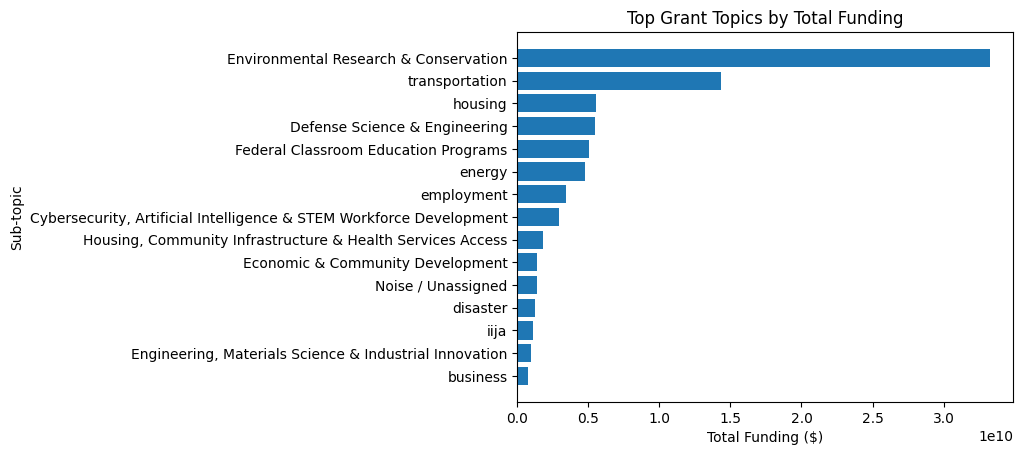

In [165]:
import matplotlib.pyplot as plt

top = topic_summary.sort_values('total_funding', ascending=False).head(15)

plt.figure()
plt.barh(top.index[::-1], top['total_funding'][::-1])
plt.title("Top Grant Topics by Total Funding")
plt.xlabel("Total Funding ($)")
plt.ylabel("Sub-topic")
plt.show()

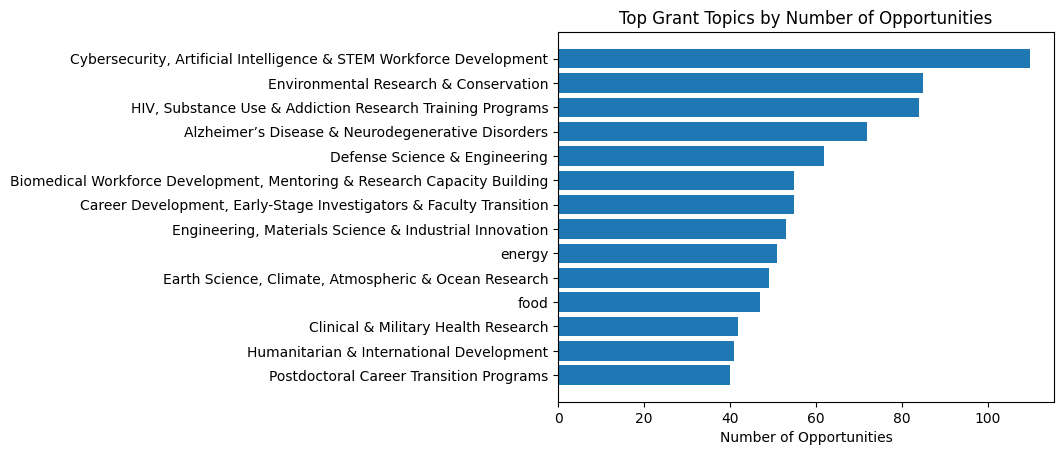

In [166]:
top = topic_summary.sort_values('n_opps', ascending=False).head(15)
top = top.drop(index='Noise / Unassigned')

plt.figure()
plt.barh(top.index[::-1], top['n_opps'][::-1])
plt.title("Top Grant Topics by Number of Opportunities")
plt.xlabel("Number of Opportunities")
plt.show()

High funding but low count → few large strategic programs

High count but lower funding → many smaller distributed grants

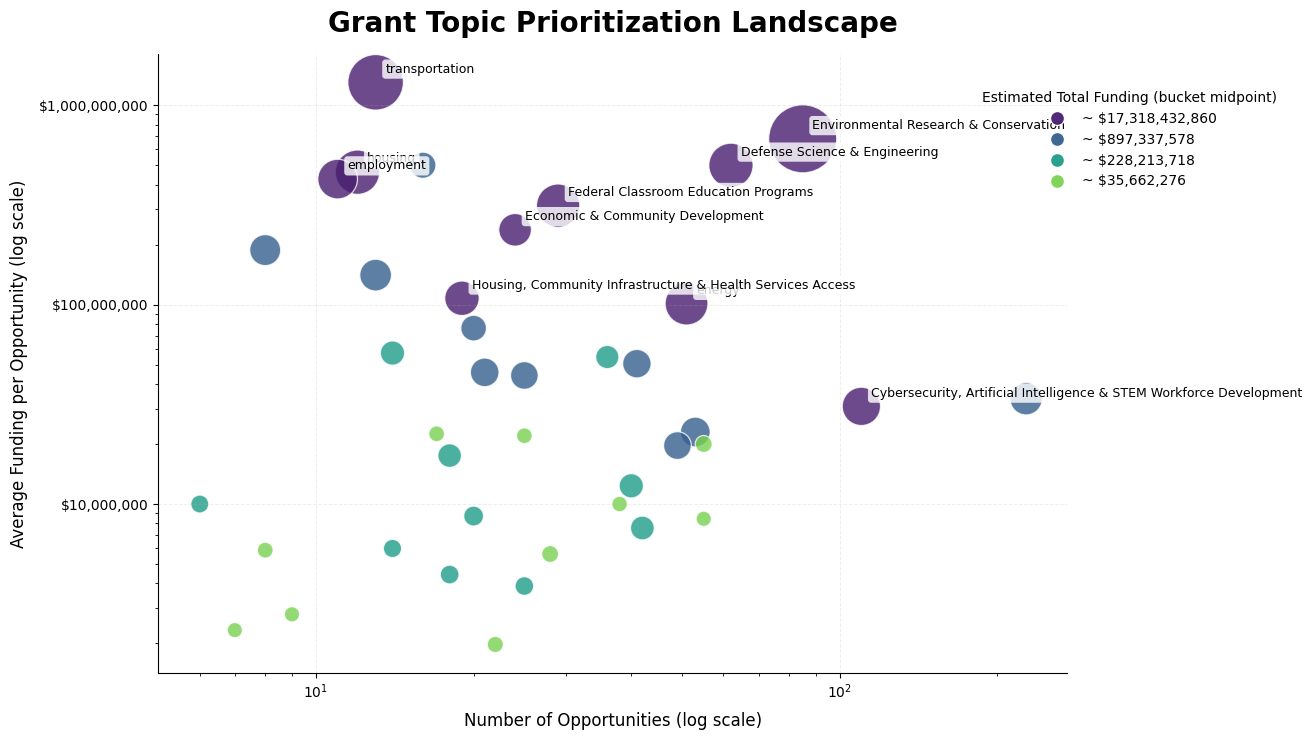

In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, LogLocator

# 1) Data prep (reset index to avoid MultiIndex issues)
ts = topic_summary.copy()

top_n = 40
top = (
    ts.sort_values('total_funding', ascending=False)
      .head(top_n)
      .reset_index()   # sub_topic becomes a normal column
      .copy()
)

# Keep valid points for log axes
top = top[(top['n_opps'] > 0) & (top['avg_funding'] > 0) & (top['total_funding'] >= 0)].copy()
fund = top['total_funding'].fillna(0).clip(lower=0)


# 2) Bubble size scaling (sqrt + cap)
size_raw = np.sqrt(fund)
s_min, s_max = 120, 2400

if size_raw.max() > 0:
    s = s_min + (size_raw - size_raw.min()) / (size_raw.max() - size_raw.min() + 1e-9) * (s_max - s_min)
else:
    s = np.full(len(top), s_min)


# 3) Funding buckets (4) + colors (lowest = lightest, highest = darkest)
qs = fund.quantile([0, 0.25, 0.5, 0.75, 1.0]).values
qs = np.unique(qs)
if len(qs) < 5:
    qs = np.linspace(fund.min(), fund.max(), 5)

bins = [qs[0], qs[1], qs[2], qs[3], qs[4]]

def money(x):
    return f"${x:,.0f}"

# Midpoints for legend labels (average of endpoints)
midpoints = [0.5 * (bins[i] + bins[i+1]) for i in range(4)]
legend_labels = [f"~ {money(m)}" for m in midpoints]

# Use the midpoints as the categorical labels
top['funding_bucket'] = pd.cut(
    fund,
    bins=bins,
    include_lowest=True,
    labels=legend_labels
)

# Assign colors
cmap = plt.cm.viridis_r
bucket_colors_light_to_dark = [cmap(v) for v in [0.20, 0.45, 0.70, 0.92]]

# Map labels in ascending funding order to colors light->dark
color_map = dict(zip(legend_labels, bucket_colors_light_to_dark))

top['color'] = top['funding_bucket'].astype(str).map(color_map)


# 4) Plot styling + layout
fig, ax = plt.subplots(figsize=(13, 7.5))

ax.scatter(
    top['n_opps'],
    top['avg_funding'],
    s=s,
    c=top['color'],
    alpha=0.80,
    edgecolors="white",
    linewidth=0.9
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Grant Topic Prioritization Landscape", fontsize=20, pad=16, weight="semibold")
ax.set_xlabel("Number of Opportunities (log scale)", fontsize=12, labelpad=8)
ax.set_ylabel("Average Funding per Opportunity (log scale)", fontsize=12, labelpad=8)

ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.22)
ax.grid(False, which="minor")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))


# 5) Label only top few points
label_n = 10
label_df = top.head(label_n)

for _, row in label_df.iterrows():
    ax.annotate(
        row['sub_topic'],
        (row['n_opps'], row['avg_funding']),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.8)
    )


# 6) Color legend (outside, fully visible)
ordered_labels = reversed(legend_labels)

color_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markersize=10,
        markerfacecolor=color_map[label],
        markeredgecolor="white",
        markeredgewidth=0.9,
        alpha=0.95,
        label=label
    )
    for label in ordered_labels
]

ax.legend(
    handles=color_handles,
    title="Estimated Total Funding (bucket midpoint)",
    loc="upper left",
    bbox_to_anchor=(0.9, 0.95),
    frameon=False,
    borderaxespad=0.0
)

# Make extra room on right so legend is not cut off
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

X = number of opportunities → activity level

Y = average funding → funding intensity

Bubble size = total funding → overall priority


**High count + high funding:**	Major national priorities

**Low count + high funding:**	Strategic flagship programs

**High count + low funding:**	Broad, distributed support

**Low count + low funding:**	Underserved niches

##**Under-Represented Topics (low volume & funding)**

In [174]:
import numpy as np

ts = topic_summary.copy()

# Avoid division by 0
ts['funding_per_opp'] = ts['total_funding'] / ts['n_opps'].replace(0, np.nan)
ts['awards_per_opp']  = ts['total_awards']  / ts['n_opps'].replace(0, np.nan)

# Log transforms help for heavy-tailed funding distributions
ts['log_total_funding'] = np.log10(ts['total_funding'].replace(0, np.nan))
ts['log_n_opps'] = np.log10(ts['n_opps'].replace(0, np.nan))

# Optional: filter to topics where funding is reasonably observed
ts_obs = ts[ts['funding_missing_rate'] <= 0.30].copy()

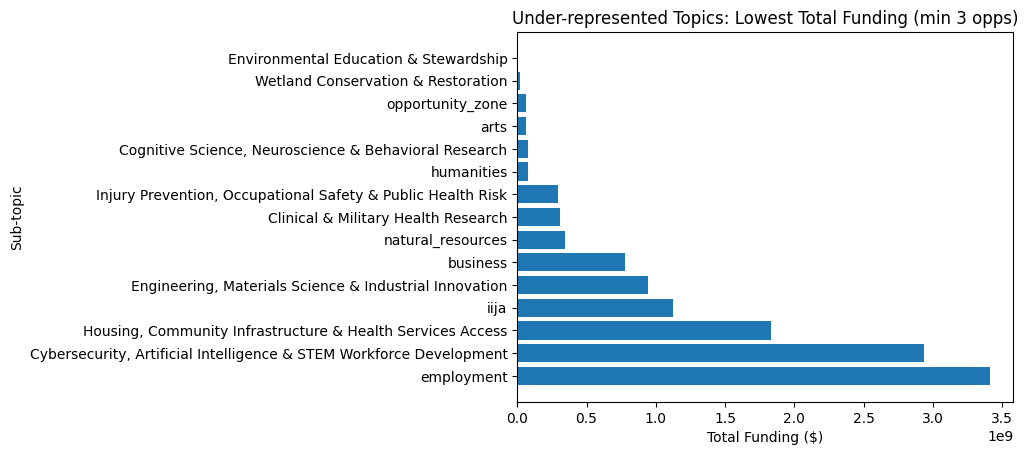

In [175]:
import matplotlib.pyplot as plt

# Require some minimum volume so you don't just pick one-off topics
bottom = ts_obs[ts_obs['n_opps'] >= 3].sort_values('total_funding', ascending=True).head(15)
bottom_sorted = bottom.sort_values('total_funding', ascending=False)

plt.figure()
plt.barh(bottom_sorted.index, bottom_sorted['total_funding'])
plt.title("Under-represented Topics: Lowest Total Funding (min 3 opps)")
plt.xlabel("Total Funding ($)")
plt.ylabel("Sub-topic")
plt.show()

**Fewest Opportunities:**

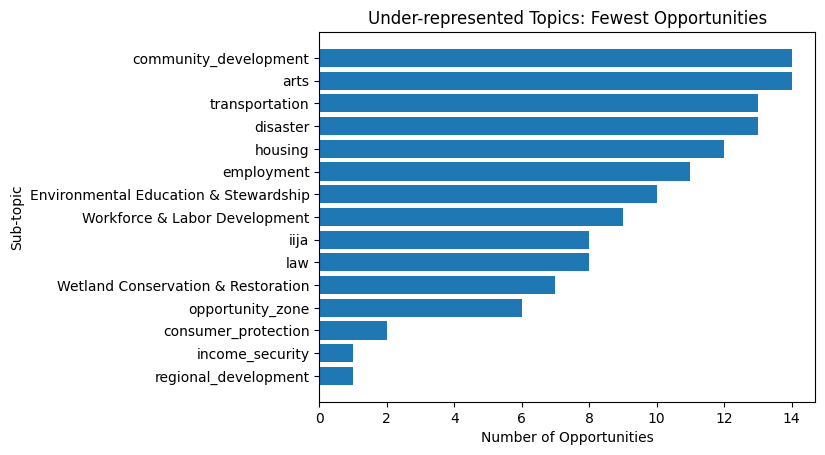

In [176]:
bottom = ts[ts['n_opps'] >= 1].sort_values('n_opps', ascending=True).head(15)

plt.figure()
plt.barh(bottom.index, bottom['n_opps'])
plt.title("Under-represented Topics: Fewest Opportunities")
plt.xlabel("Number of Opportunities")
plt.ylabel("Sub-topic")
plt.show()

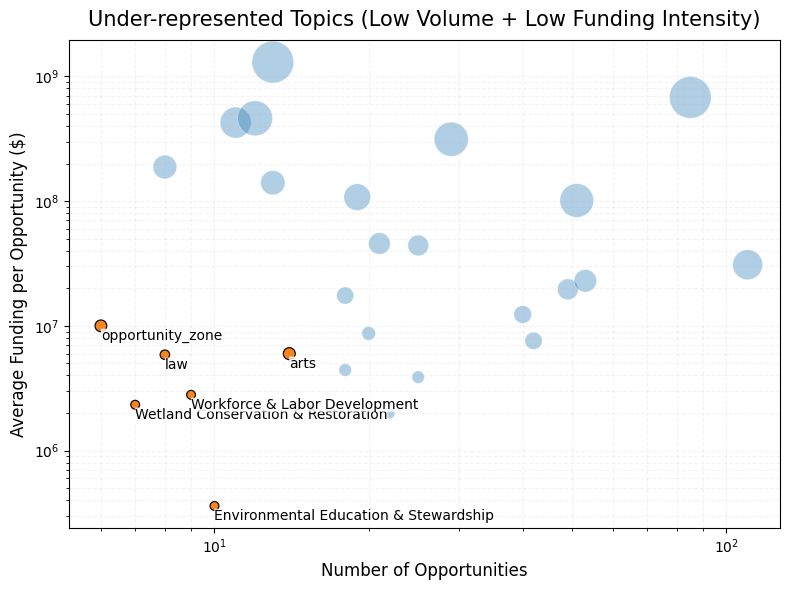

In [363]:
ts = topic_summary.copy()

# --- filter to reasonably observed funding + valid values ---
df = ts[(ts['funding_missing_rate'] <= 0.50) &
        (ts['n_opps'] >= 2) &
        (ts['avg_funding'] > 0) &
        (ts['total_funding'] > 0)].copy()

# --- under-represented = bottom quartile in BOTH (on log scale) ---
logx = np.log10(df['n_opps'])
logy = np.log10(df['avg_funding'])
q = 0.40
df['under_rep'] = (logx <= logx.quantile(q)) & (logy <= logy.quantile(q))
ur = df[df['under_rep']]

# --- bubble sizes: robust scaling so giant topics don't dominate ---
s = np.sqrt(df['total_funding'])
lo, hi = np.percentile(s, [5, 95])
s = np.clip(s, lo, hi)
df['size'] = 40 + (s - s.min()) / (s.max() - s.min() + 1e-9) * (900 - 40)

# --- plot ---
plt.figure(figsize=(8, 6))
plt.scatter(df['n_opps'], df['avg_funding'], s=df['size'], alpha=0.35, edgecolors="white", linewidth=0.6)
plt.scatter(ur['n_opps'], ur['avg_funding'], s=df.loc[ur.index, 'size'], alpha=0.95, edgecolors="black", linewidth=0.9)

for topic, r in ur.iterrows():
    wrapped_list = textwrap.wrap(topic, width=40)
    wrapped_text = '\n'.join(wrapped_list)
    plt.annotate(wrapped_text, (r['n_opps'], r['avg_funding']),
                 xytext=(0, -10), textcoords="offset points", #ha='left', rotation=-5,
                 fontsize=10, bbox=dict(boxstyle="round,pad=0", fc="white", ec="none", alpha=0.85))

plt.title("Under-represented Topics (Low Volume + Low Funding Intensity)", fontsize=15, pad=10)
plt.xlabel("Number of Opportunities", fontsize=12)
plt.ylabel("Average Funding per Opportunity ($)", fontsize=12)
plt.xscale("log")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.15)
plt.tight_layout()
plt.show()

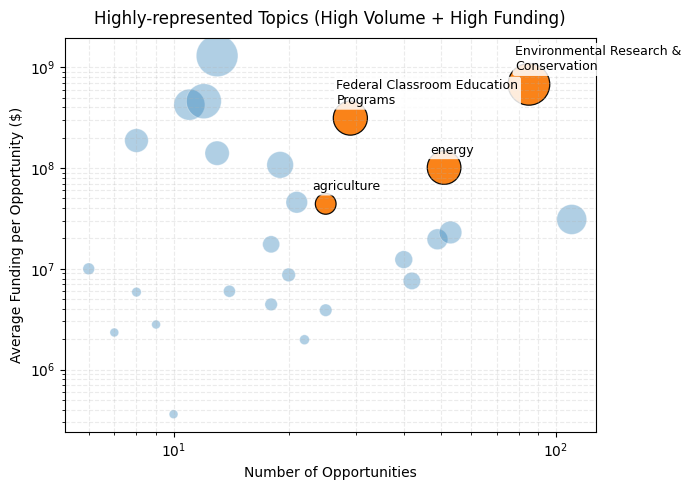

In [342]:
import textwrap
# --- under-represented = bottom quartile in BOTH (on log scale) ---
logx = np.log10(df['n_opps'])
logy = np.log10(df['avg_funding'])
logt = np.log10(df['total_funding'])
q = 0.60
df['high_rep'] = (logx >= logx.quantile(q)) & (logy >= logy.quantile(q))
# df['high_rep'] = (logt >= logt.quantile(q))
ur = df[df['high_rep']]

# --- bubble sizes: robust scaling so giant topics don't dominate ---
s = np.sqrt(df['total_funding'])
lo, hi = np.percentile(s, [5, 95])
s = np.clip(s, lo, hi)
df['size'] = 40 + (s - s.min()) / (s.max() - s.min() + 1e-9) * (900 - 40)

# --- plot ---
plt.figure(figsize=(7, 5))
plt.scatter(df['n_opps'], df['avg_funding'], s=df['size'], alpha=0.35, edgecolors="white", linewidth=0.6)
plt.scatter(ur['n_opps'], ur['avg_funding'], s=df.loc[ur.index, 'size'], alpha=0.95, edgecolors="black", linewidth=0.9)

for topic, r in ur.iterrows():
    wrapped_list = textwrap.wrap(topic, width=30)
    wrapped_text = '\n'.join(wrapped_list)
    plt.annotate(wrapped_text, (r['n_opps'], r['avg_funding']),
                 xytext=(-10, 10), textcoords="offset points",
                 fontsize=9, bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))

plt.title("Highly-represented Topics (High Volume + High Funding)", fontsize=12, pad=10)
plt.xlabel("Number of Opportunities", fontsize=10)
plt.ylabel("Average Funding per Opportunity ($)", fontsize=10)
plt.xscale("log")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()

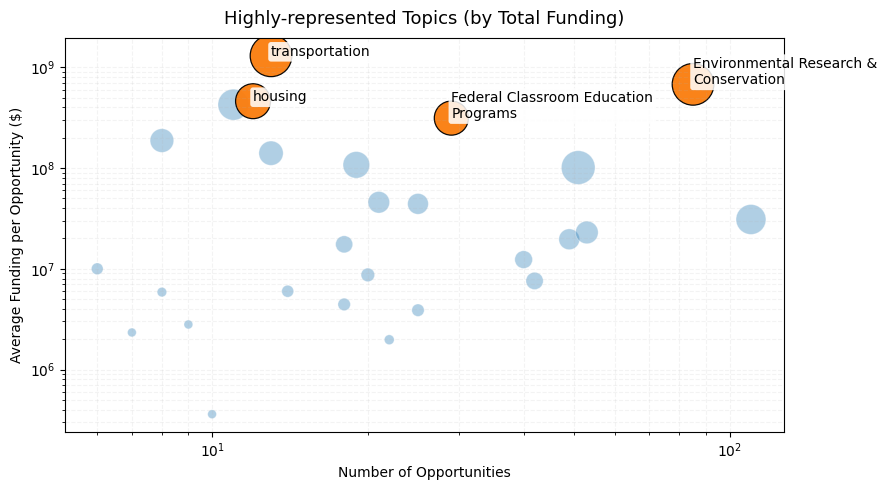

In [303]:
import textwrap
# --- under-represented = bottom quartile in BOTH (on log scale) ---
logx = np.log10(df['n_opps'])
logy = np.log10(df['avg_funding'])
logt = np.log10(df['total_funding'])
q = 0.85
# df['high_rep'] = (logx >= logx.quantile(q)) & (logy >= logy.quantile(q))
df['high_rep'] = (logt >= logt.quantile(q))
ur = df[df['high_rep']]

# --- bubble sizes: robust scaling so giant topics don't dominate ---
s = np.sqrt(df['total_funding'])
lo, hi = np.percentile(s, [5, 95])
s = np.clip(s, lo, hi)
df['size'] = 40 + (s - s.min()) / (s.max() - s.min() + 1e-9) * (900 - 40)

# --- plot ---
plt.figure(figsize=(9, 5))
plt.scatter(df['n_opps'], df['avg_funding'], s=df['size'], alpha=0.35, edgecolors="white", linewidth=0.6)
plt.scatter(ur['n_opps'], ur['avg_funding'], s=df.loc[ur.index, 'size'], alpha=0.95, edgecolors="black", linewidth=0.9)

for topic, r in ur.iterrows():
    wrapped_list = textwrap.wrap(topic, width=30)
    wrapped_text = '\n'.join(wrapped_list)
    plt.annotate(wrapped_text, (r['n_opps'], r['avg_funding']),
                 xytext=(0, 0), textcoords="offset points",
                 fontsize=10, bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))

plt.title("Highly-represented Topics (by Total Funding)", fontsize=13, pad=10)
plt.xlabel("Number of Opportunities", fontsize=10)
plt.ylabel("Average Funding per Opportunity ($)", fontsize=10)
plt.xscale("log")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.15)
plt.tight_layout()
plt.show()

# **Integrations**

## **Grant Agency Funding Profiles: Top Sub-Topics**

### Get Clusters

In [228]:
grants['expected_awards_num'] = pd.to_numeric(grants['expected_number_of_awards'], errors='coerce')

agency_profile = (grants.groupby('agency_name')
                  .agg(
                      n_opps=('opportunity_id','count'),
                      avg_funding=('estimated_funding','mean'),
                      med_funding=('estimated_funding', 'median'),
                      avg_awards=('expected_awards_num','mean'),
                      med_awards=('expected_awards_num', 'median'),
                      funding_missing_rate=('estimated_funding', lambda s: s.isna().mean())
                  )
                  .reset_index())

agency_profile.sort_values('n_opps', ascending=False).head(10)

# Choosing my Features
features = agency_profile[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].copy()

# Create Log Features --> directly into dataframe
features.loc[:, 'log_n_opps'] = np.log1p(features['n_opps'])
features.loc[:, 'log_med_funding'] = np.log1p(features['med_funding'])
features.loc[:, 'log_med_awards'] = np.log1p(features['med_awards'])

# Final Feature Set Before Clustering
features = features[['log_n_opps', 'log_med_funding', 'log_med_awards', 'funding_missing_rate']].copy()

In [229]:
# KMeans cannot handle NaNs, rows with missing data will be removed for clustering
features.isna().sum().sort_values(ascending=False)
features_clean = features.dropna()

In [230]:
#Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_clean)

In [231]:
#Running K-Means & Picking 4 as my k

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

#Attatch Cluster Labels to Agencies
agency_profile_clean = agency_profile.loc[features_clean.index].copy()
agency_profile_clean['cluster'] = clusters


In [232]:
#Profile the Clusters

cluster_summary = agency_profile_clean.groupby('cluster')[['n_opps',
                                                           'med_funding',
                                                           'med_awards',
                                                           'funding_missing_rate'
                                                           ]].median()

cluster_summary

,n_opps,med_funding,med_awards,funding_missing_rate
cluster,,,,
0,7.0,225000.0,3.0,0.083333
1,24.0,3000000.0,1.0,0.583333
2,11.0,11250000.0,40.0,0.037037
3,145.5,1650000.0,2.0,0.116531


In [233]:
# Assign descriptive labels for interpretability
cluster_labels = {
    0: "Lower Funding / Smaller Awards",
    1: "Moderate Funding, Few Awards",
    2: "High Funding Agencies",
    3: "High Opportunity Agencies"}

agency_profile_clean['cluster_label'] = agency_profile_clean['cluster'].map(cluster_labels)

In [234]:
# Keep only what you need
agency_clusters = agency_profile_clean[['agency_name', 'cluster', 'cluster_label']].copy()

# Merge agency cluster back to grants dataframe
grants_with_agency_cluster = grants.merge(
    agency_clusters,
    on='agency_name',
    how='left'
)

### Merge DFs

In [235]:
agency_merged_df = details.merge(
    grants_with_agency_cluster[['opportunity_id', 'cluster', 'cluster_label']],
    on='opportunity_id',
    how='inner'   # use inner since you only want overlapping rows
)

In [237]:
print("Merged DF size:", agency_merged_df.shape[0])
print("Missing agency clusters:", agency_merged_df['cluster'].isna().sum())

Merged DF size: 2000
Missing agency clusters: 29


In [239]:
merged_df_clean = agency_merged_df.dropna(subset=['cluster'])

print("Original merged size:", merged_df_clean.shape[0])
print("Clean merged size:", merged_df_clean.shape[0])

Original merged size: 1971
Clean merged size: 1971


In [240]:
merged_df_clean['agency_cluster'] = merged_df_clean['cluster_label']

High_Funding_Agencies = merged_df_clean[merged_df_clean['agency_cluster'] == 'High Funding Agencies']
High_Opportunity_Agencies = merged_df_clean[merged_df_clean['agency_cluster'] == 'High Opportunity Agencies']
Lower_Funding_Smaller_Awards = merged_df_clean[merged_df_clean['agency_cluster'] == 'Lower Funding / Smaller Awards']
Moderate_Funding_Few_Awards = merged_df_clean[merged_df_clean['agency_cluster'] == 'Moderate Funding, Few Awards']

/tmp/ipython-input-711/3842042883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_clean['agency_cluster'] = merged_df_clean['cluster_label']


In [252]:
merged_df_clean['agency_cluster'].value_counts()

,count
agency_cluster,
High Opportunity Agencies,1664
"Moderate Funding, Few Awards",221
High Funding Agencies,63
Lower Funding / Smaller Awards,23


### **Analysis**

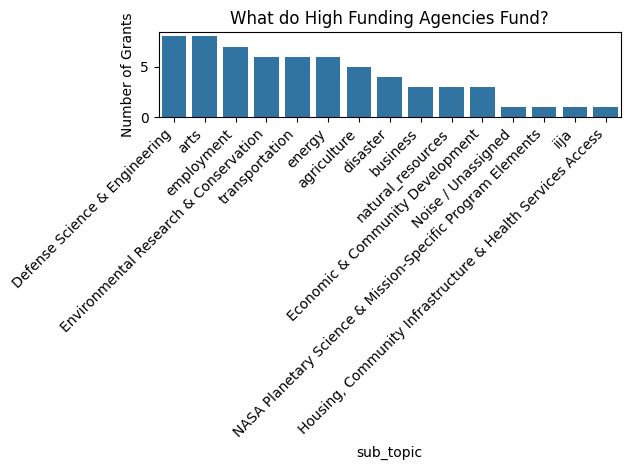

In [251]:
import seaborn as sns

# Graph Topics per Agency Cluster
high_fund_order = High_Funding_Agencies['sub_topic'].value_counts().index

# High_Funding_Agencies_top = High_Funding_Agencies[High_Funding_Agencies['sub_topic'].isin(high_fund_order[:10])]

count_plot = sns.countplot(
    data=High_Funding_Agencies,
    x='sub_topic',
#    hue='official_category',
    order=high_fund_order
)
plt.title("What do High Funding Agencies Fund?")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')

# Wrap x-axis labels
# wrapped_labels = [textwrap.fill(label, 30) for label in High_Funding_Agencies_top['sub_topic']]
# plt.xticks(ticks=range(len(wrapped_labels)), labels=wrapped_labels, rotation=45, ha='right')

# plt.legend(
#     title='category',
#     bbox_to_anchor=(1.05, 1),
#     loc='upper left',
#     borderaxespad=0
# )
plt.tight_layout()
plt.show()

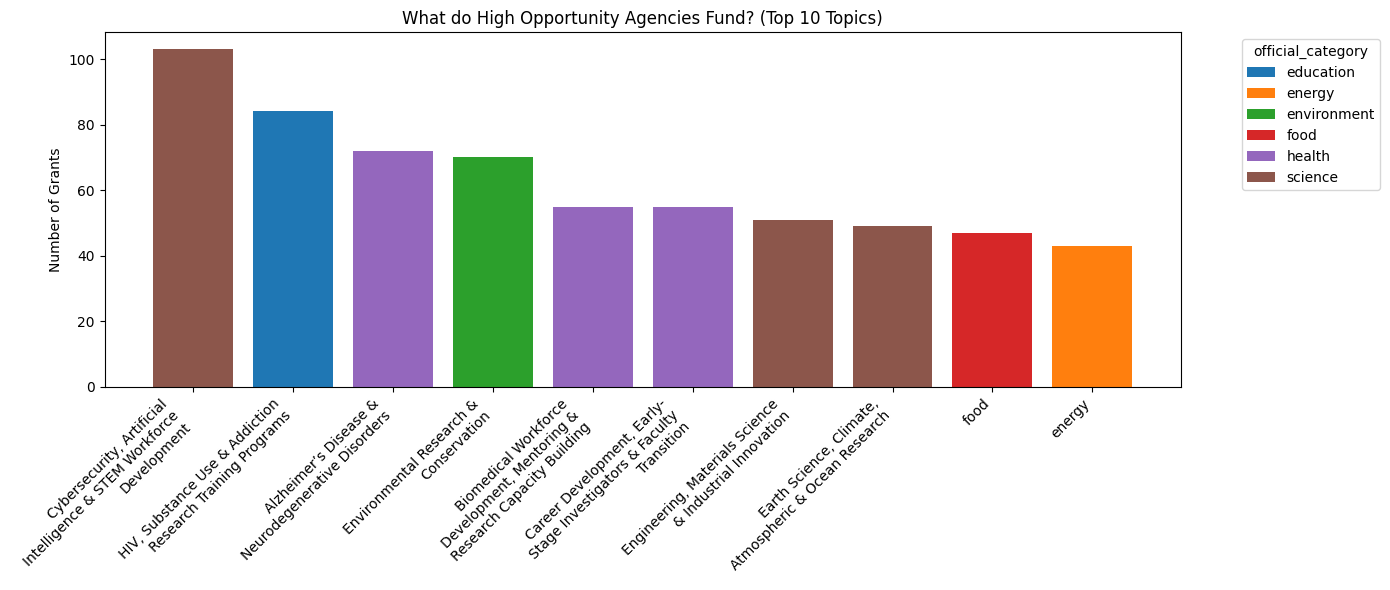

In [258]:
order = High_Opportunity_Agencies['sub_topic'].value_counts().index

top_15 = High_Opportunity_Agencies[High_Opportunity_Agencies['sub_topic'].isin(order[1:11])]

count_data = (
    top_15
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
)
count_data = count_data.loc[order[1:11]]

plt.figure(figsize=(14, 6))

bottom = np.zeros(len(count_data))

for category in count_data.columns:
    plt.bar(
        count_data.index,
        count_data[category],
        bottom=bottom,
        label=category
    )
    bottom += count_data[category]

plt.title("What do High Opportunity Agencies Fund? (Top 10 Topics)")
plt.ylabel("Number of Grants")
wrapped_labels = [textwrap.fill(label, 30) for label in count_data.index]
plt.xticks(ticks=range(len(wrapped_labels)), labels=wrapped_labels, rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

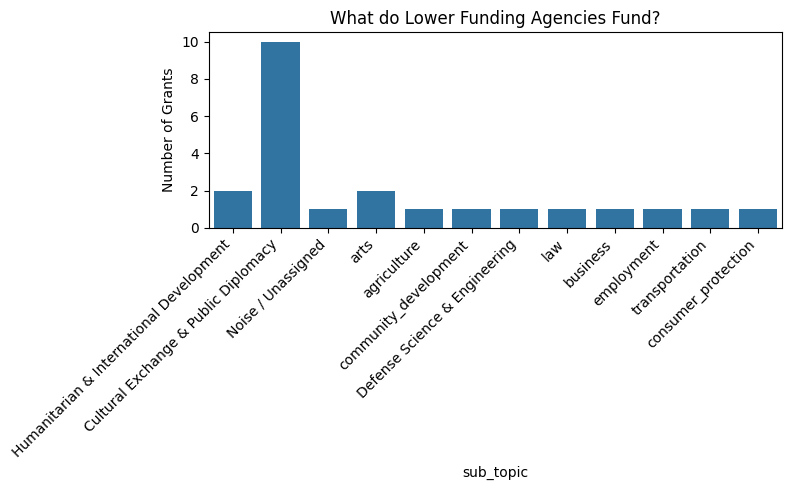

In [259]:
fig, ax = plt.subplots(figsize=(8, 5))

count_plot = sns.countplot(
    data=Lower_Funding_Smaller_Awards,
    x='sub_topic'
)
plt.title("What do Lower Funding Agencies Fund?")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

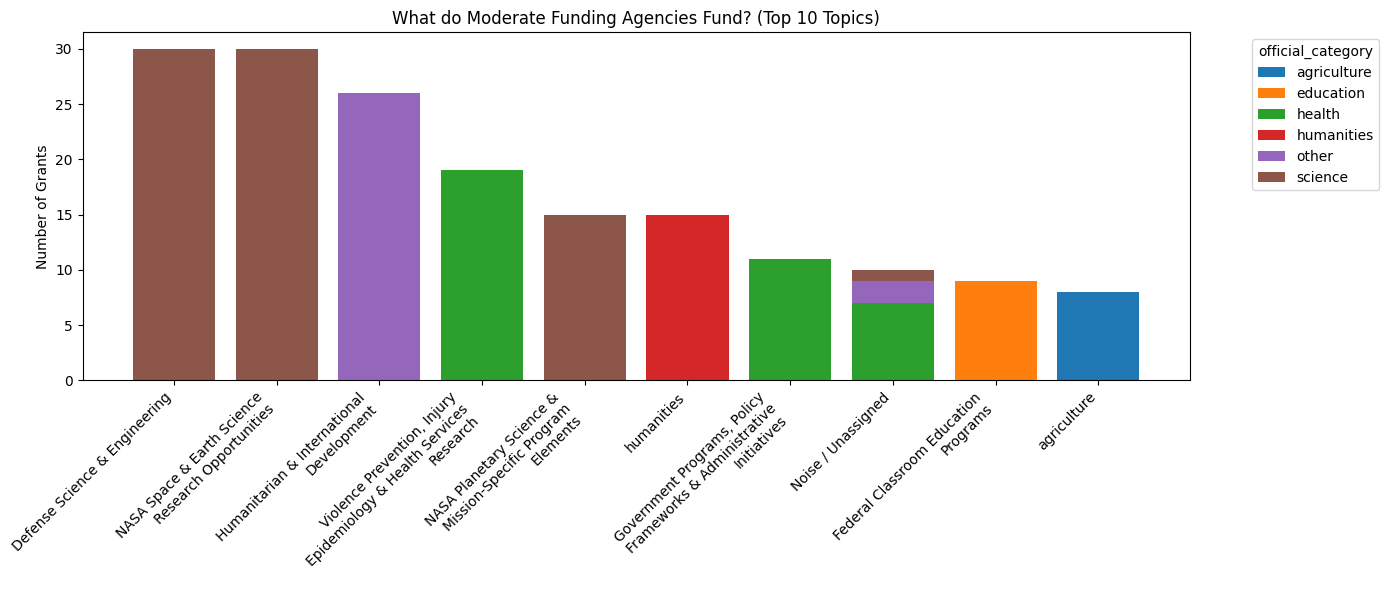

In [261]:
moderate_order = Moderate_Funding_Few_Awards['sub_topic'].value_counts().index

moderate_top_15 = Moderate_Funding_Few_Awards[Moderate_Funding_Few_Awards['sub_topic'].isin(moderate_order[:10])]

moderate_data = (
    moderate_top_15
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
)
moderate_data = moderate_data.loc[moderate_order[:10]]

plt.figure(figsize=(14, 6))

bottom = np.zeros(len(moderate_data))

for category in moderate_data.columns:
    plt.bar(
        moderate_data.index,
        moderate_data[category],
        bottom=bottom,
        label=category
    )
    bottom += moderate_data[category]

plt.title("What do Moderate Funding Agencies Fund? (Top 10 Topics)")
plt.ylabel("Number of Grants")
wrapped_labels = [textwrap.fill(label, 30) for label in moderate_data.index]
plt.xticks(ticks=range(len(wrapped_labels)), labels=wrapped_labels, rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

##**Grant Eligibility Types: Top Sub-Topics**

### Get Clusters

In [213]:
# Identify eligibility columns
elig_cols = [col for col in details.columns if col.startswith("eligibility_")]

# Select relevant columns from grants: opportunity_id, estimated_funding, agency_name
grants_subset = grants[['opportunity_id', 'estimated_funding', 'agency_name']]

# Merge with eligibility data
merged = details.merge(grants_subset, on='opportunity_id', how='left')

# Extract eligibility matrix for clustering
X_elig = merged[elig_cols]

In [214]:
!pip install kmodes

from kmodes.kmodes import KModes

# Run K-Modes with 3 clusters (same number as K-Means for comparison)
km = KModes(n_clusters=3, init='Huang', n_init=5, random_state=42)
km_labels = km.fit_predict(X_elig)

# Add labels to merged dataset
merged['kmodes_cluster'] = km_labels

### Merge DFs

In [215]:
eligibility_merged_df = details.merge(
    merged[['opportunity_id', 'kmodes_cluster']],
    on='opportunity_id',
    how='inner'   # use inner since you only want overlapping rows
)

In [216]:
eligibility_merged_df['kmodes_cluster'].isna().sum()

np.int64(0)

### **Analysis**

In [217]:
# elibilitity cluster mapping
elig_cluster_labels = {
    0: "Broad Institutional Eligibility",
    1: "Minimal/Unspecified Eligbility",
    2: "Fully Unrestricted Eligibility"}

eligibility_merged_df['eligibility_cluster'] = eligibility_merged_df['kmodes_cluster'].map(elig_cluster_labels)

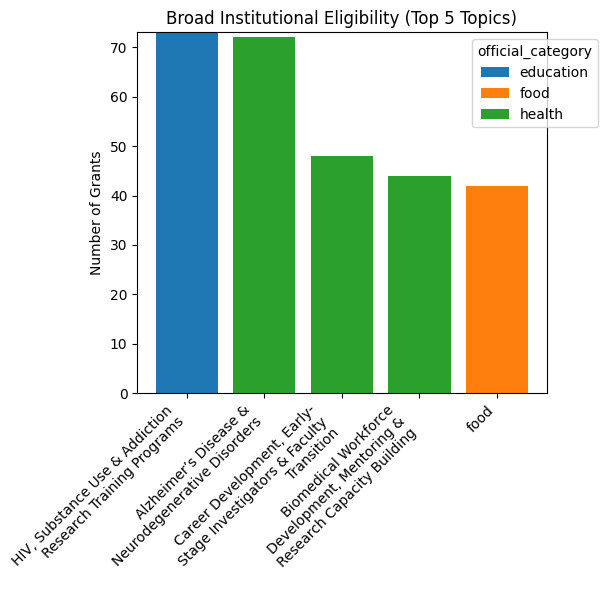

In [293]:
import textwrap

# Graph Topics per Eligibility Cluster
broad_cluster = eligibility_merged_df[eligibility_merged_df['eligibility_cluster'] == "Broad Institutional Eligibility"]
minimal_cluster = eligibility_merged_df[eligibility_merged_df['eligibility_cluster'] == "Minimal/Unspecified Eligbility"]
unrestricted_cluster = eligibility_merged_df[eligibility_merged_df['eligibility_cluster'] == 'Fully Unrestricted Eligibility']

order_0 = broad_cluster['sub_topic'].value_counts().index

top_10_broad = broad_cluster[broad_cluster['sub_topic'].isin(order_0[1:6])]

count_data_broad = (
    top_10_broad
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
).loc[order_0[1:6]]

plt.figure(figsize=(6, 6))

bottom = np.zeros(len(count_data_broad))

for category in count_data_broad.columns:
    plt.bar(
        count_data_broad.index,
        count_data_broad[category],
        bottom=bottom,
        label=category
    )
    bottom += count_data_broad[category]

plt.title("Broad Institutional Eligibility (Top 5 Topics)")
plt.ylabel("Number of Grants")
plt.xlabel("")

# Wrap x-axis labels
wrapped_labels = [textwrap.fill(label, 30) for label in count_data_broad.index]
plt.xticks(ticks=range(len(wrapped_labels)), labels=wrapped_labels, rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(0.8, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

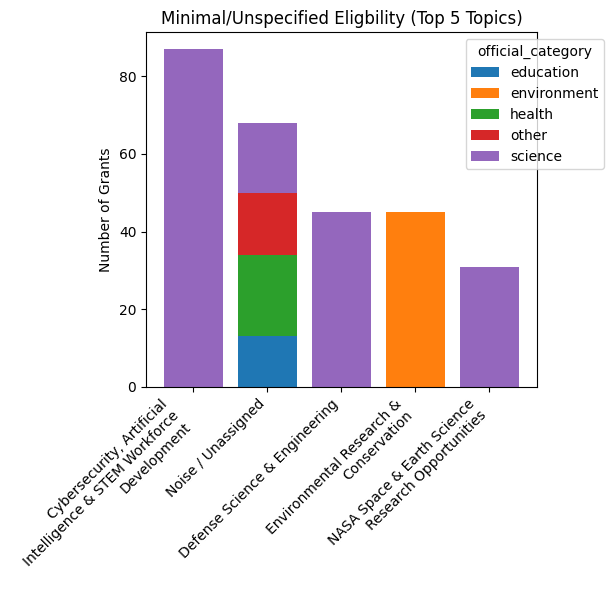

In [292]:
order_1 = minimal_cluster['sub_topic'].value_counts().index

top_10_min = minimal_cluster[minimal_cluster['sub_topic'].isin(order_1[:5])]

count_data_min = (
    top_10_min
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
).loc[order_1[:5]]

plt.figure(figsize=(6, 6))

bottom = np.zeros(len(count_data_min))

for category in count_data_min.columns:
    plt.bar(
        count_data_min.index,
        count_data_min[category],
        bottom=bottom,
        label=category
    )
    bottom += count_data_min[category]

plt.title("Minimal/Unspecified Eligbility (Top 5 Topics)")
plt.ylabel("Number of Grants")
plt.xlabel("")
wrapped_labels = [textwrap.fill(label, 30) for label in count_data_min.index]
plt.xticks(ticks=range(len(wrapped_labels)), labels=wrapped_labels, rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(0.80, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

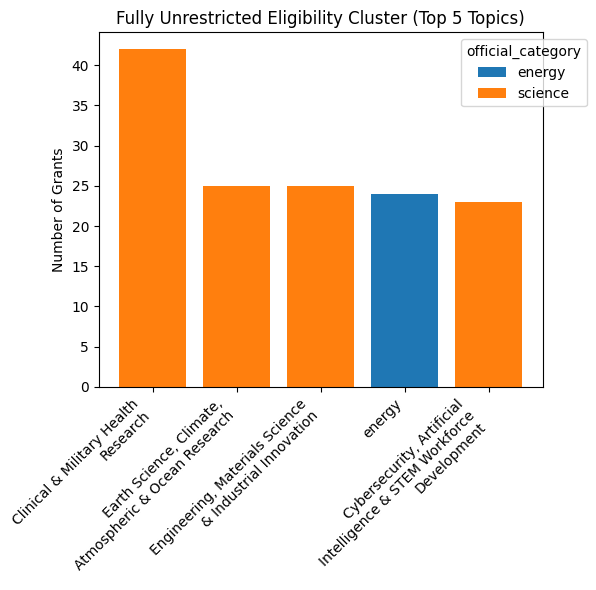

In [290]:
order_2 = unrestricted_cluster['sub_topic'].value_counts().index


top_10_unres = unrestricted_cluster[unrestricted_cluster['sub_topic'].isin(order_2[:5])]

count_data_unres = (
    top_10_unres
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
).loc[order_2[:5]]

plt.figure(figsize=(6, 6))

bottom = np.zeros(len(count_data_unres))

for category in count_data_unres.columns:
    plt.bar(
        count_data_unres.index,
        count_data_unres[category],
        bottom=bottom,
        label=category
    )
    bottom += count_data_unres[category]

plt.title("Fully Unrestricted Eligibility Cluster (Top 5 Topics)")
plt.ylabel("Number of Grants")
plt.xlabel("")
wrapped_labels = [textwrap.fill(label, 30) for label in count_data_unres.index]
plt.xticks(ticks=range(len(wrapped_labels)), labels=wrapped_labels, rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(0.8, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

# **Gen AI Disclaimer**

I used ChatGPT to help compare model evaluation metrics, label clusters based on key words, and format model comparisons into a single clean code pipeline. I also used it to help improve visualization interpretability.

Link to prompts: https://chatgpt.com/share/69a75662-3590-8007-ab62-c444aff2a77a

## Widget Removal

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pip install nbformat

import nbformat

notebook_path = '/content/drive/MyDrive/MSBA Spring 2026/820 ML Group Project/M5 Work/Notebooks/Maggie_Croghan_M5.ipynb'  # change to your filename

output_path = "Maggie_Croghan_M5_clean.ipynb"

nb = nbformat.read(notebook_path, as_version=4)

# Remove notebook-level widget metadata safely
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

# Remove widgets from cell metadata and outputs
for cell in nb.cells:
    # Remove cell-level widget metadata
    if "widgets" in cell.metadata:
        del cell.metadata["widgets"]

    # Remove widget outputs
    if "outputs" in cell:
        cleaned_outputs = []
        for output in cell["outputs"]:
            if "data" in output:
                if any("widget" in key for key in output["data"].keys()):
                    continue
            cleaned_outputs.append(output)
        cell["outputs"] = cleaned_outputs

nbformat.write(nb, output_path)

print("Clean notebook written to:", output_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/MSBA Spring 2026/820 ML Group Project/M5 Work/Notebooks/Maggie_Croghan_M5.ipynb'